# DANA8411 — Conceptual Framework for Scaled Agile Success
## Exploratory Data Analysis (EDA)

### What is this notebook?

This notebook analyses a **survey about Scaled Agile** — a way of managing large software projects using flexible, team-based approaches (like SAFe — the Scaled Agile Framework). 

**60 professionals** from various roles (developers, scrum masters, project managers, agile coaches, etc.) filled in the survey. They rated different agile practices and success indicators on a **1–5 Likert scale**:

| Score | Meaning |
|-------|---------|
| 1 | Strongly Disagree / Not at all important |
| 2 | Disagree / Slightly important |
| 3 | Neutral / Moderately important |
| 4 | Agree / Important |
| 5 | Strongly Agree / Extremely important |

---

### Why are we doing this?

The research aims to build a **"conceptual framework"** — a model that explains what makes Scaled Agile projects succeed. To do that, we need to understand:
- Which practices are seen as most **important**?
- Are organisations actually **implementing** those practices?
- How do processes relate to project **success**?

---

### What does the survey cover?

| Section | What it's asking | # Questions |
|---------|-----------------|-------------|
| **Q1–Q4** | About the respondent — experience level and role | 4 |
| **Q6** | How *important* are **Portfolio-level** processes? (governance, funding, planning) | 5 |
| **Q7** | How *important* are **ART-level** events? (PI Planning, System Demo, CI/CD, etc.) | 8 |
| **Q8** | How *important* are **Team-level** capabilities? (build, test, deploy, define) | 5 |
| **Q9** | Are Portfolio processes actually being **implemented**? | 5 |
| **Q10** | Are ART events actually being **implemented**? | 8 |
| **Q11** | Are Team capabilities actually being **implemented**? | 5 |
| **Q12** | What does **Enterprise-level success** look like? (goals met, market impact, governance) | 12 |
| **Q13** | What does **Programme-level success** look like? | 5 |
| **Q14** | What does **Customer/product success** look like? | 6 |

> 💡 **Key thing to note:** Q6/7/8 = *what should be done (importance)* and Q9/10/11 = *what is actually being done (implementation)*. Comparing these tells us where teams are falling short.

## 1 — Setup & Imports

**What's happening here?**  
We're loading the Python libraries (tools) we need for the analysis. Think of each library as a specialist tool:

- **`pandas`** — reads and manipulates the Excel data (like a programmable spreadsheet)
- **`numpy`** — handles maths and number crunching
- **`matplotlib` & `seaborn`** — create all the graphs and charts
- **`scipy.stats`** — runs statistical tests (like ANOVA) to check if patterns are real or just noise

We also set a consistent colour palette and style for all charts so everything looks clean and professional.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#2563EB', '#7C3AED', '#DB2777', '#EA580C', '#16A34A', '#0891B2']
LIKERT_COLORS = ['#DC2626', '#F97316', '#EAB308', '#22C55E', '#16A34A']  # 1→5
sns.set_palette(PALETTE)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2 — Load & Label the Data

**What's happening here?**  
We load the Excel file and do two things to make the data easier to work with:

1. **Rename the columns** — the original column names are massive paragraphs copied from the survey questions (e.g. *"6.1 Lean governance: The leadership, organisational structures and streamlined processes..."*). We shorten them to clean codes like `p6_lean_gov` so they fit on charts. The prefix tells you what section it's from:
   - `p6_` / `p7_` / `p8_` = **importance** questions (Portfolio / ART / Team)
   - `i9_` / `i10_` / `i11_` = **implementation** questions (Portfolio / ART / Team)
   - `s12_` / `s13_` / `s14_` = **success indicator** questions

2. **Decode the demographic numbers** — the Excel stores demographics as numbers (e.g. role `1` = Scrum Master, `13` = Other). We convert these to human-readable labels so charts say "Scrum Master" instead of "1".

> ⚠️ **Data issue found:** The survey accidentally includes two versions of the Q6.1 "Lean Governance" column — one with a typo in the original question text. These two columns are NOT identical (correlation = -0.17), suggesting they captured slightly different responses. We keep the clean version and drop the typo duplicate in the next step.

In [25]:
df_raw = pd.read_excel('Scaled_Agile_Survey_Responses.xlsx')

# ── Short column names for cleaner plots ──────────────────────────────────────
col_map = {
    df_raw.columns[0]: 'agile_exp',
    df_raw.columns[1]: 'scaled_agile_exp',
    df_raw.columns[2]: 'business_unit',
    df_raw.columns[3]: 'role',
    # Section 6 — Portfolio importance
    df_raw.columns[4]:  'p6_lean_gov',
    df_raw.columns[5]:  'p6_lean_gov_2',
    df_raw.columns[6]:  'p6_value_stream',
    df_raw.columns[7]:  'p6_prog_selection',
    df_raw.columns[8]:  'p6_portfolio_opt',
    df_raw.columns[9]:  'p6_strategy_funding',
    # Section 7 — ART importance
    df_raw.columns[10]: 'p7_pi_planning',
    df_raw.columns[11]: 'p7_system_demo',
    df_raw.columns[12]: 'p7_inspect_adapt',
    df_raw.columns[13]: 'p7_cont_exploration',
    df_raw.columns[14]: 'p7_cont_integration',
    df_raw.columns[15]: 'p7_cont_deployment',
    df_raw.columns[16]: 'p7_compliance',
    df_raw.columns[17]: 'p7_release_demand',
    # Section 8 — Team importance
    df_raw.columns[18]: 'p8_delivery',
    df_raw.columns[19]: 'p8_define',
    df_raw.columns[20]: 'p8_build',
    df_raw.columns[21]: 'p8_test',
    df_raw.columns[22]: 'p8_deploy',
    # Section 9 — Portfolio implementation
    df_raw.columns[23]: 'i9_lean_gov',
    df_raw.columns[24]: 'i9_value_stream',
    df_raw.columns[25]: 'i9_prog_selection',
    df_raw.columns[26]: 'i9_portfolio_opt',
    df_raw.columns[27]: 'i9_strategy_funding',
    # Section 10 — ART implementation
    df_raw.columns[28]: 'i10_pi_planning',
    df_raw.columns[29]: 'i10_system_demo',
    df_raw.columns[30]: 'i10_inspect_adapt',
    df_raw.columns[31]: 'i10_cont_exploration',
    df_raw.columns[32]: 'i10_cont_integration',
    df_raw.columns[33]: 'i10_cont_deployment',
    df_raw.columns[34]: 'i10_compliance',
    df_raw.columns[35]: 'i10_release_demand',
    # Section 11 — Team implementation
    df_raw.columns[36]: 'i11_delivery',
    df_raw.columns[37]: 'i11_define',
    df_raw.columns[38]: 'i11_build',
    df_raw.columns[39]: 'i11_test',
    df_raw.columns[40]: 'i11_deploy',
    # Section 12 — Enterprise success
    df_raw.columns[41]: 's12_goals_met',
    df_raw.columns[42]: 's12_governance',
    df_raw.columns[43]: 's12_benefits_realise',
    df_raw.columns[44]: 's12_market_impact',
    df_raw.columns[45]: 's12_industry_impact',
    df_raw.columns[46]: 's12_competitive',
    df_raw.columns[47]: 's12_investor',
    df_raw.columns[48]: 's12_regulator',
    df_raw.columns[49]: 's12_portfolio_financial',
    df_raw.columns[50]: 's12_strategy_alignment',
    df_raw.columns[51]: 's12_product_balance',
    df_raw.columns[52]: 's12_product_success',
    # Section 13 — Programme success
    df_raw.columns[53]: 's13_ownership_benefits',
    df_raw.columns[54]: 's13_benefit_alignment',
    df_raw.columns[55]: 's13_compliance',
    df_raw.columns[56]: 's13_strategy_align',
    df_raw.columns[57]: 's13_stakeholder_eng',
    # Section 14 — Customer success
    df_raw.columns[58]: 's14_specs_met',
    df_raw.columns[59]: 's14_customer_accept',
    df_raw.columns[60]: 's14_cust_satisfaction',
    df_raw.columns[61]: 's14_schedule_budget',
    df_raw.columns[62]: 's14_product_used',
    df_raw.columns[63]: 's14_delivery',
}

df = df_raw.rename(columns=col_map)

# ── Decode categorical labels ─────────────────────────────────────────────────
agile_exp_labels = {
    1: '< 1 yr', 2: '1–2 yrs', 3: '2–3 yrs',
    4: '3–5 yrs', 5: '5–8 yrs', 6: '8+ yrs'
}
scaled_agile_labels = {
    1: '< 1 yr', 2: '1–2 yrs', 3: '2–3 yrs',
    4: '3–5 yrs', 5: '5–8 yrs', 6: '8+ yrs', 7: 'None'
}
business_unit_labels = {
    1: 'IT', 3: 'Finance', 7: 'Operations',
    8: 'HR', 10: 'Product', 11: 'Other'
}
role_labels = {
    1: 'Scrum Master', 2: 'Product Owner', 3: 'Developer',
    4: 'Tester/QA', 6: 'Agile Coach', 7: 'Release Train Eng',
    8: 'Portfolio Mgr', 9: 'Project Mgr', 11: 'Business Analyst',
    12: 'Architect', 13: 'Other'
}

df['agile_exp_label']        = df['agile_exp'].map(agile_exp_labels)
df['scaled_agile_exp_label'] = df['scaled_agile_exp'].map(scaled_agile_labels)
df['business_unit_label']    = df['business_unit'].map(business_unit_labels)
df['role_label']             = df['role'].map(role_labels)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Dataset shape: 60 rows × 68 columns


,agile_exp,scaled_agile_exp,business_unit,role,p6_lean_gov,p6_lean_gov_2,p6_value_stream,p6_prog_selection,p6_portfolio_opt,p6_strategy_funding,...,s14_specs_met,s14_customer_accept,s14_cust_satisfaction,s14_schedule_budget,s14_product_used,s14_delivery,agile_exp_label,scaled_agile_exp_label,business_unit_label,role_label
0,2,7,1,13,3,3,4,3,4,4,...,1.0,3.0,3.0,3.0,3.0,3.0,1–2 yrs,None,IT,Other
1,1,1,1,13,5,4,4,5,4,4,...,3.0,2.0,4.0,4.0,2.0,4.0,< 1 yr,< 1 yr,IT,Other
2,1,1,1,13,5,2,1,3,2,3,...,1.0,2.0,2.0,1.0,2.0,2.0,< 1 yr,< 1 yr,IT,Other


## 3 — Data Quality Check

**What's happening here?**  
Before we analyse anything, we need to check if the data is clean and complete. This is standard practice — garbage in, garbage out. We're checking for:

- **Missing values** — did anyone skip a question? If so, how many and which ones?
- **Valid range** — are all scores between 1 and 5 as expected? No weird values like 99 or 0?
- **Duplicate rows** — did anyone accidentally submit the survey twice with identical answers?

**What we found:**
- 11 missing values across 7 questions — mostly in the Customer Success section (Q14). This is very minor (less than 2% of all data points).
- All scores are valid (1–5 range confirmed).
- No duplicate rows.

**How we handle missing values:**  
We fill the 11 missing values with the **median** (middle score) for that question. This is called *median imputation* — it's a safe approach for small amounts of missing data because the median isn't skewed by extreme values. With only 11 missing values out of 3,540 total data points (0.3%), this has virtually no impact on the results.

In [26]:
scale_cols = [c for c in df.columns if c.startswith(('p6_','p7_','p8_','i9_','i10_','i11_','s12_','s13_','s14_'))]
scale_cols = [c for c in scale_cols if c != 'p6_lean_gov']  # drop duplicate Q6.1 (typo variant)
demo_cols  = ['agile_exp','scaled_agile_exp','business_unit','role']

print('=' * 55)
print('  DATA QUALITY SUMMARY')
print('=' * 55)
print(f'  Respondents          : {len(df)}')
print(f'  Total columns        : {len(col_map)}')
print(f'  Likert-scale items   : {len(scale_cols)}')
print(f'  Demographic items    : {len(demo_cols)}')
print()
miss = df[scale_cols].isnull().sum()
miss_cols = miss[miss > 0]
print(f'  Missing values (scale items): {miss.sum()}')
if len(miss_cols):
    print(f'  Columns with missing : {list(miss_cols.index)}')
    print(f'  Max missing in col   : {miss_cols.max()} / {len(df)}')
else:
    print('  No missing values in scale items')
print()
print(f'  Likert value range: {int(df[scale_cols].min().min())} – {int(df[scale_cols].max().max())}')

# Duplicate check
dups = df[scale_cols].duplicated().sum()
print(f'  Duplicate response rows  : {dups}')
print()
print('  Dtypes:')
print(f'    int64   : {(df[scale_cols].dtypes == "int64").sum()}')
print(f'    float64 : {(df[scale_cols].dtypes == "float64").sum()}')

  DATA QUALITY SUMMARY
  Respondents          : 60
  Total columns        : 64
  Likert-scale items   : 59
  Demographic items    : 4

  Missing values (scale items): 11
  Columns with missing : ['s13_stakeholder_eng', 's14_specs_met', 's14_customer_accept', 's14_cust_satisfaction', 's14_schedule_budget', 's14_product_used', 's14_delivery']
  Max missing in col   : 2 / 60

  Likert value range: 1 – 5
  Duplicate response rows  : 0

  Dtypes:
    int64   : 52
    float64 : 7


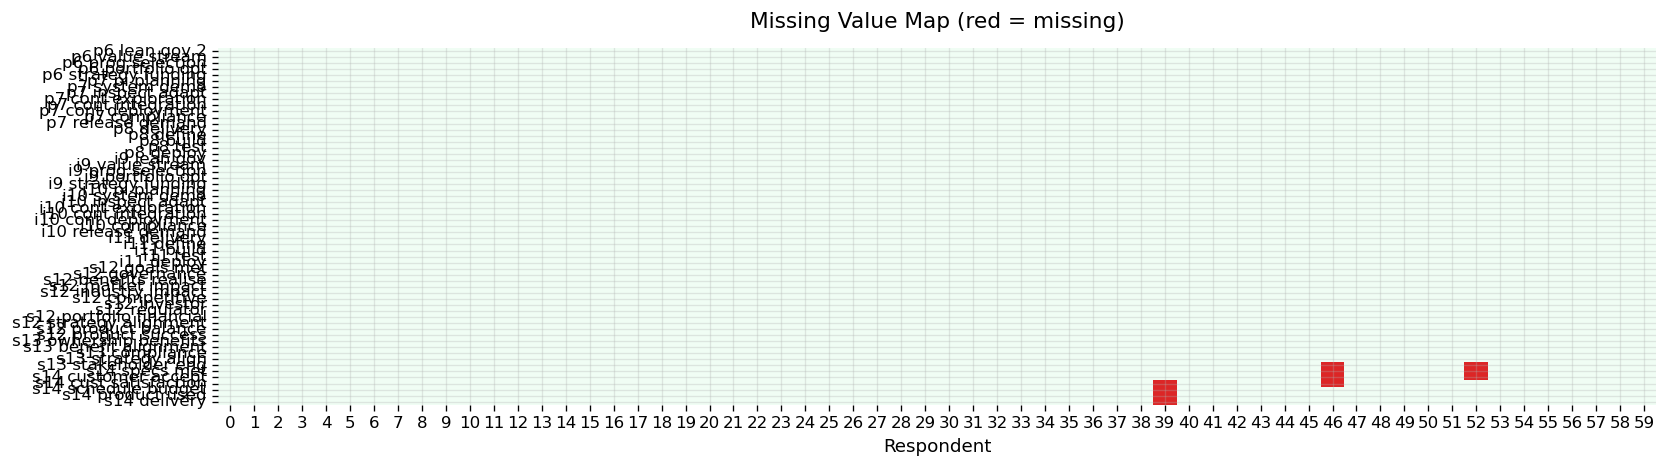

Missing values after imputation: 0


In [27]:
# Missing value heatmap
miss_matrix = df[scale_cols].isnull()
if miss_matrix.any().any():
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(miss_matrix.T, cmap=['#F0FDF4','#DC2626'], cbar=False,
                yticklabels=[c.replace('_',' ') for c in scale_cols], ax=ax)
    ax.set_title('Missing Value Map (red = missing)', pad=12)
    ax.set_xlabel('Respondent')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values — no heatmap needed')

# Impute missing with column median (minimal impact — max 2 missing per col)
for c in scale_cols:
    df[c].fillna(df[c].median(), inplace=True)

print('Missing values after imputation:', df[scale_cols].isnull().sum().sum())

## 4 — Who Responded? (Demographics)

**What's happening here?**  
We're building a picture of *who* answered the survey. Understanding the respondents is important because their perspectives are shaped by their experience and role. A developer and a portfolio manager will have very different views on what "success" looks like.

We're looking at four demographic questions:
- **Agile Experience** — how long have they been working in Agile generally?
- **Scaled Agile Experience** — how long specifically in Scaled Agile (SAFe, LeSS, etc.)?
- **Business Unit** — which part of the organisation do they work in?
- **Role** — what is their job title / function?

The charts use bar charts for experience (ordered from least to most), a pie chart for business unit (to show proportions), and a horizontal bar chart for role (easier to read long labels).

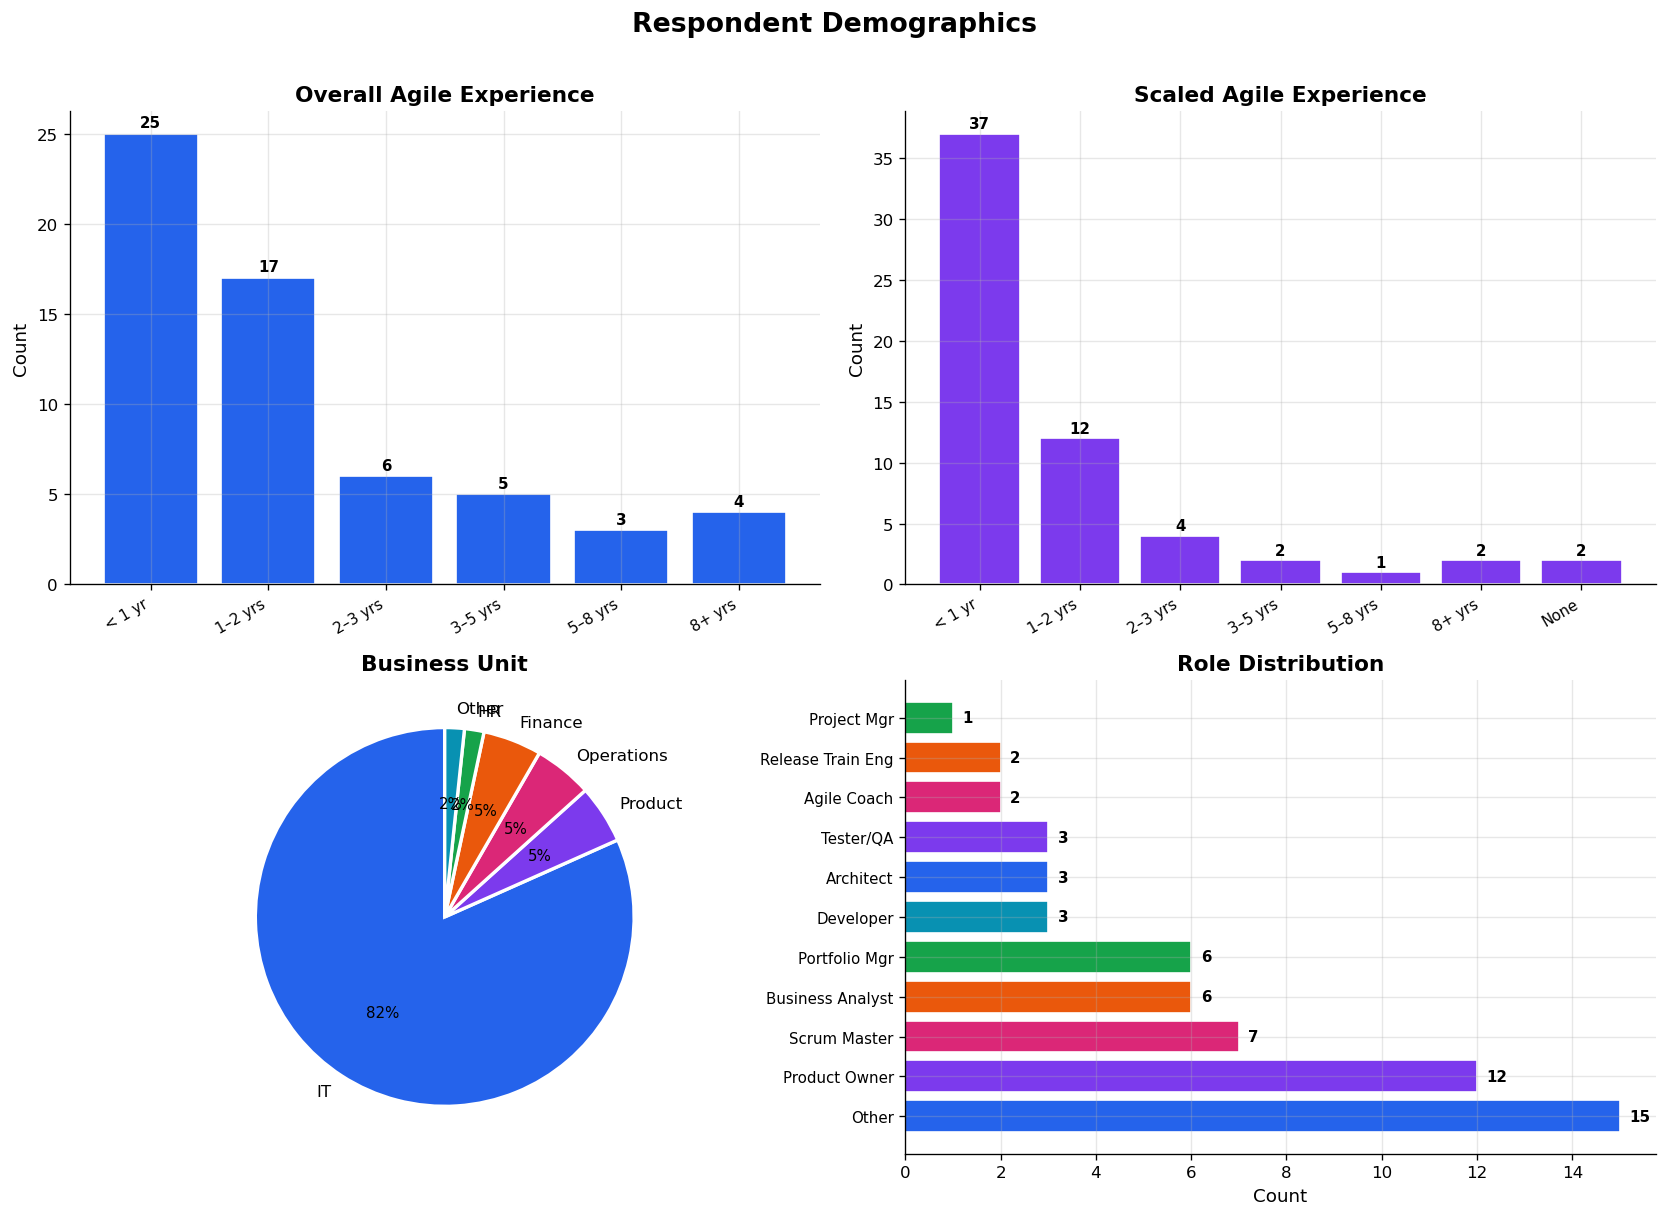

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Respondent Demographics', fontsize=16, fontweight='bold', y=1.01)

def plot_bar(ax, col, title, color):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(range(len(vc)), vc.values, color=color, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Agile experience
order = ['< 1 yr','1–2 yrs','2–3 yrs','3–5 yrs','5–8 yrs','8+ yrs']
vc1 = df['agile_exp_label'].value_counts().reindex(order).dropna()
bars1 = axes[0,0].bar(range(len(vc1)), vc1.values, color=PALETTE[0], edgecolor='white')
axes[0,0].set_xticks(range(len(vc1)))
axes[0,0].set_xticklabels(vc1.index, rotation=30, ha='right', fontsize=9)
axes[0,0].set_title('Overall Agile Experience', fontweight='bold')
axes[0,0].set_ylabel('Count')
for b in bars1:
    axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2, str(int(b.get_height())),
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# Scaled Agile experience
order2 = ['< 1 yr','1–2 yrs','2–3 yrs','3–5 yrs','5–8 yrs','8+ yrs','None']
vc2 = df['scaled_agile_exp_label'].value_counts().reindex(order2).dropna()
bars2 = axes[0,1].bar(range(len(vc2)), vc2.values, color=PALETTE[1], edgecolor='white')
axes[0,1].set_xticks(range(len(vc2)))
axes[0,1].set_xticklabels(vc2.index, rotation=30, ha='right', fontsize=9)
axes[0,1].set_title('Scaled Agile Experience', fontweight='bold')
axes[0,1].set_ylabel('Count')
for b in bars2:
    axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.2, str(int(b.get_height())),
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# Business unit
vc3 = df['business_unit_label'].value_counts()
wedges, texts, autotexts = axes[1,0].pie(
    vc3.values, labels=vc3.index, autopct='%1.0f%%',
    colors=PALETTE[:len(vc3)], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontsize(9)
axes[1,0].set_title('Business Unit', fontweight='bold')

# Role
vc4 = df['role_label'].value_counts()
bars4 = axes[1,1].barh(range(len(vc4)), vc4.values,
                        color=[PALETTE[i % len(PALETTE)] for i in range(len(vc4))],
                        edgecolor='white')
axes[1,1].set_yticks(range(len(vc4)))
axes[1,1].set_yticklabels(vc4.index, fontsize=9)
axes[1,1].set_title('Role Distribution', fontweight='bold')
axes[1,1].set_xlabel('Count')
for b in bars4:
    axes[1,1].text(b.get_width()+0.2, b.get_y()+b.get_height()/2,
                   str(int(b.get_width())), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

## 5 — Descriptive Statistics

**What's happening here?**  
Before diving into fancy charts, we compute the basic summary statistics for every single survey question. This gives us a quick snapshot of the data.

**What the numbers mean:**
- **Mean** — the average score. Above 3.5 = generally positive, below 2.5 = generally negative
- **Std Dev (Standard Deviation)** — how spread out the scores are. A high std dev (e.g. 1.0+) means people strongly disagreed with each other. A low std dev means most people gave similar answers.
- **Min / Max** — the lowest and highest score given
- **Q1 / Median / Q3** — the "middle half" of responses. If Q1=3 and Q3=4, then half of all respondents scored between 3 and 4.

**The bar chart** shows the average score for each of the 9 survey sections, with error bars showing the standard deviation (how much disagreement existed within each section). The dashed line at 3.0 = the neutral point.

In [29]:
desc = df[scale_cols].describe().T[['mean','std','min','25%','50%','75%','max']]
desc.columns = ['Mean','Std Dev','Min','Q1','Median','Q3','Max']
desc = desc.round(3)

# Section labels
def section_label(col):
    if col.startswith('p6'): return 'Portfolio (Importance)'
    if col.startswith('p7'): return 'ART (Importance)'
    if col.startswith('p8'): return 'Team (Importance)'
    if col.startswith('i9'): return 'Portfolio (Implementation)'
    if col.startswith('i10'): return 'ART (Implementation)'
    if col.startswith('i11'): return 'Team (Implementation)'
    if col.startswith('s12'): return 'Enterprise Success'
    if col.startswith('s13'): return 'Programme Success'
    if col.startswith('s14'): return 'Customer Success'
    return 'Other'

desc['Section'] = [section_label(c) for c in desc.index]
print(desc.to_string())

                          Mean  Std Dev  Min    Q1  Median    Q3  Max                     Section
p6_lean_gov_2            3.550    0.964  1.0  3.00     4.0  4.00  5.0      Portfolio (Importance)
p6_value_stream          3.717    0.993  1.0  3.00     4.0  4.00  5.0      Portfolio (Importance)
p6_prog_selection        3.717    0.885  1.0  3.00     4.0  4.00  5.0      Portfolio (Importance)
p6_portfolio_opt         3.617    0.804  1.0  3.00     4.0  4.00  5.0      Portfolio (Importance)
p6_strategy_funding      3.767    0.831  1.0  3.75     4.0  4.00  5.0      Portfolio (Importance)
p7_pi_planning           3.183    0.965  1.0  3.00     3.0  4.00  5.0            ART (Importance)
p7_system_demo           3.800    0.819  1.0  3.00     4.0  4.00  5.0            ART (Importance)
p7_inspect_adapt         3.450    0.928  1.0  3.00     3.5  4.00  5.0            ART (Importance)
p7_cont_exploration      3.667    0.774  2.0  3.00     4.0  4.00  5.0            ART (Importance)
p7_cont_integration 

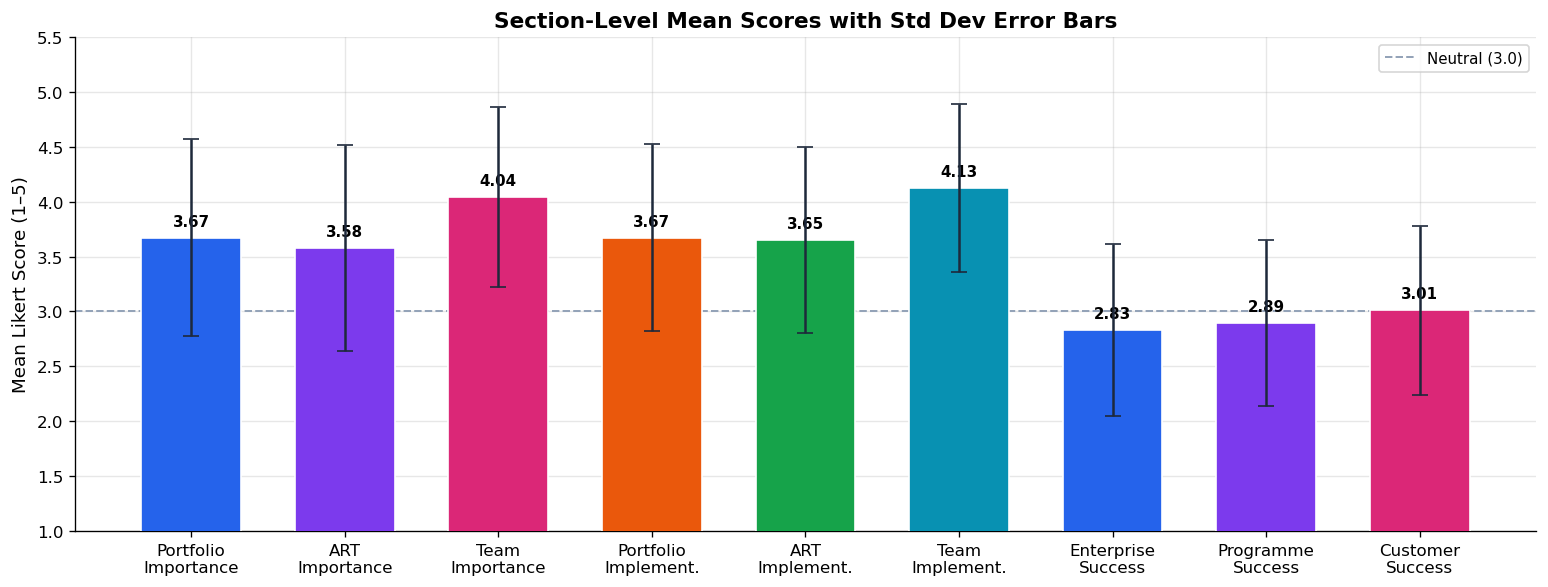

In [30]:
# Section-level averages
section_groups = {
    'Portfolio\nImportance': [c for c in scale_cols if c.startswith('p6')],
    'ART\nImportance':       [c for c in scale_cols if c.startswith('p7')],
    'Team\nImportance':      [c for c in scale_cols if c.startswith('p8')],
    'Portfolio\nImplement.': [c for c in scale_cols if c.startswith('i9')],
    'ART\nImplement.':       [c for c in scale_cols if c.startswith('i10')],
    'Team\nImplement.':      [c for c in scale_cols if c.startswith('i11')],
    'Enterprise\nSuccess':   [c for c in scale_cols if c.startswith('s12')],
    'Programme\nSuccess':    [c for c in scale_cols if c.startswith('s13')],
    'Customer\nSuccess':     [c for c in scale_cols if c.startswith('s14')],
}

section_means = {k: df[v].values.flatten().mean() for k, v in section_groups.items()}
section_stds  = {k: df[v].values.flatten().std()  for k, v in section_groups.items()}

fig, ax = plt.subplots(figsize=(13, 5))
keys = list(section_means.keys())
vals = [section_means[k] for k in keys]
errs = [section_stds[k]  for k in keys]

bars = ax.bar(keys, vals, color=PALETTE * 2, edgecolor='white', width=0.65, zorder=3)
ax.errorbar(range(len(keys)), vals, yerr=errs, fmt='none',
            color='#1E293B', capsize=5, linewidth=1.5, zorder=4)
ax.axhline(3, color='#94A3B8', linestyle='--', linewidth=1.2, label='Neutral (3.0)')
ax.set_ylim(1, 5.5)
ax.set_ylabel('Mean Likert Score (1–5)')
ax.set_title('Section-Level Mean Scores with Std Dev Error Bars', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.08,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_section_means.png', bbox_inches='tight', dpi=150)
plt.show()

## 6 — Likert Distribution Charts (Diverging Bar Charts)

**What's happening here?**  
We're creating **diverging stacked bar charts** — the best way to visualise Likert-scale survey data.

**How to read these charts:**
- Each row = one survey question
- The bars extend left (negative = disagree) and right (positive = agree)
- The **centre line (0)** represents the neutral point
- 🔴 Red = Strongly Disagree (1), 🟠 Orange = Disagree (2), 🟡 Yellow = Neutral (3), 🟢 Light Green = Agree (4), 🟩 Dark Green = Strongly Agree (5)
- If the bar is mostly on the **right side** → respondents generally agree / find it important
- If the bar is mostly on the **left side** → respondents generally disagree / don't value it

**What we're comparing:**
- **Portfolio Importance (Q6) vs Portfolio Implementation (Q9)** — are the things people say matter actually being done?
- **ART Importance (Q7) vs ART Implementation (Q10)** — same question at the Agile Release Train level
- **Success Indicators (Q12/13/14)** — how do people rate enterprise, programme, and customer success?

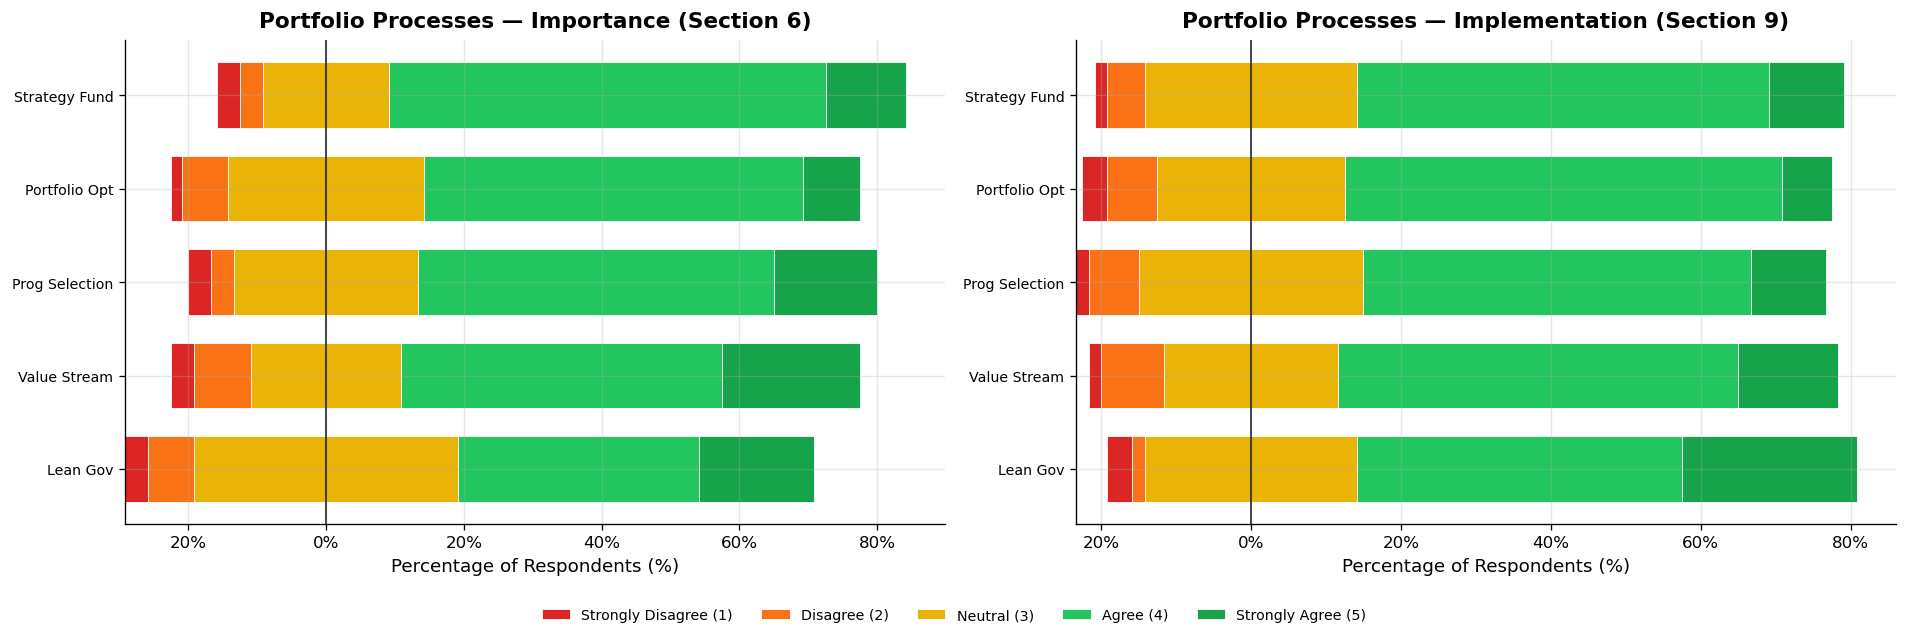

In [31]:
def likert_diverging(ax, cols, title, short_labels=None):
    """Diverging stacked bar chart centred at neutral (3)."""
    data = df[cols].round().astype(int)
    if short_labels is None:
        short_labels = [c.split('_', 1)[1].replace('_',' ') for c in cols]

    pcts = {i: (data == i).sum() / len(data) * 100 for i in range(1, 6)}
    neutral = pcts[3] / 2
    lefts = -(pcts[1] + pcts[2] + neutral)

    colors = LIKERT_COLORS
    labels = ['Strongly Disagree (1)','Disagree (2)','Neutral (3)',
              'Agree (4)','Strongly Agree (5)']

    current_lefts = lefts.copy()
    for idx, (score, color, label) in enumerate(zip(range(1, 6), colors, labels)):
        widths = pcts[score].values if score != 3 else pcts[3].values
        if score < 3:
            ax.barh(range(len(cols)), pcts[score].values,
                    left=current_lefts.values, color=color, edgecolor='white',
                    linewidth=0.5, label=label, height=0.7)
            current_lefts = current_lefts + pcts[score]
        elif score == 3:
            ax.barh(range(len(cols)), pcts[score].values,
                    left=current_lefts.values, color=color, edgecolor='white',
                    linewidth=0.5, label=label, height=0.7)
            current_lefts = current_lefts + pcts[score]
        else:
            ax.barh(range(len(cols)), pcts[score].values,
                    left=current_lefts.values, color=color, edgecolor='white',
                    linewidth=0.5, label=label, height=0.7)
            current_lefts = current_lefts + pcts[score]

    ax.axvline(0, color='#1E293B', linewidth=1)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(short_labels, fontsize=8.5)
    ax.set_xlabel('Percentage of Respondents (%)')
    ax.set_title(title, fontweight='bold', pad=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x):.0f}%'))
    return ax

# ── Portfolio Importance vs Implementation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

p6_cols   = [c for c in scale_cols if c.startswith('p6')]
p6_labels = ['Lean Gov','Value Stream','Prog Selection','Portfolio Opt','Strategy Fund']
likert_diverging(axes[0], p6_cols, 'Portfolio Processes — Importance (Section 6)', p6_labels)

i9_cols   = [c for c in scale_cols if c.startswith('i9')]
i9_labels = ['Lean Gov','Value Stream','Prog Selection','Portfolio Opt','Strategy Fund']
likert_diverging(axes[1], i9_cols, 'Portfolio Processes — Implementation (Section 9)', i9_labels)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=5, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.07), frameon=False)
plt.tight_layout()
plt.savefig('fig_portfolio_likert.png', bbox_inches='tight', dpi=150)
plt.show()

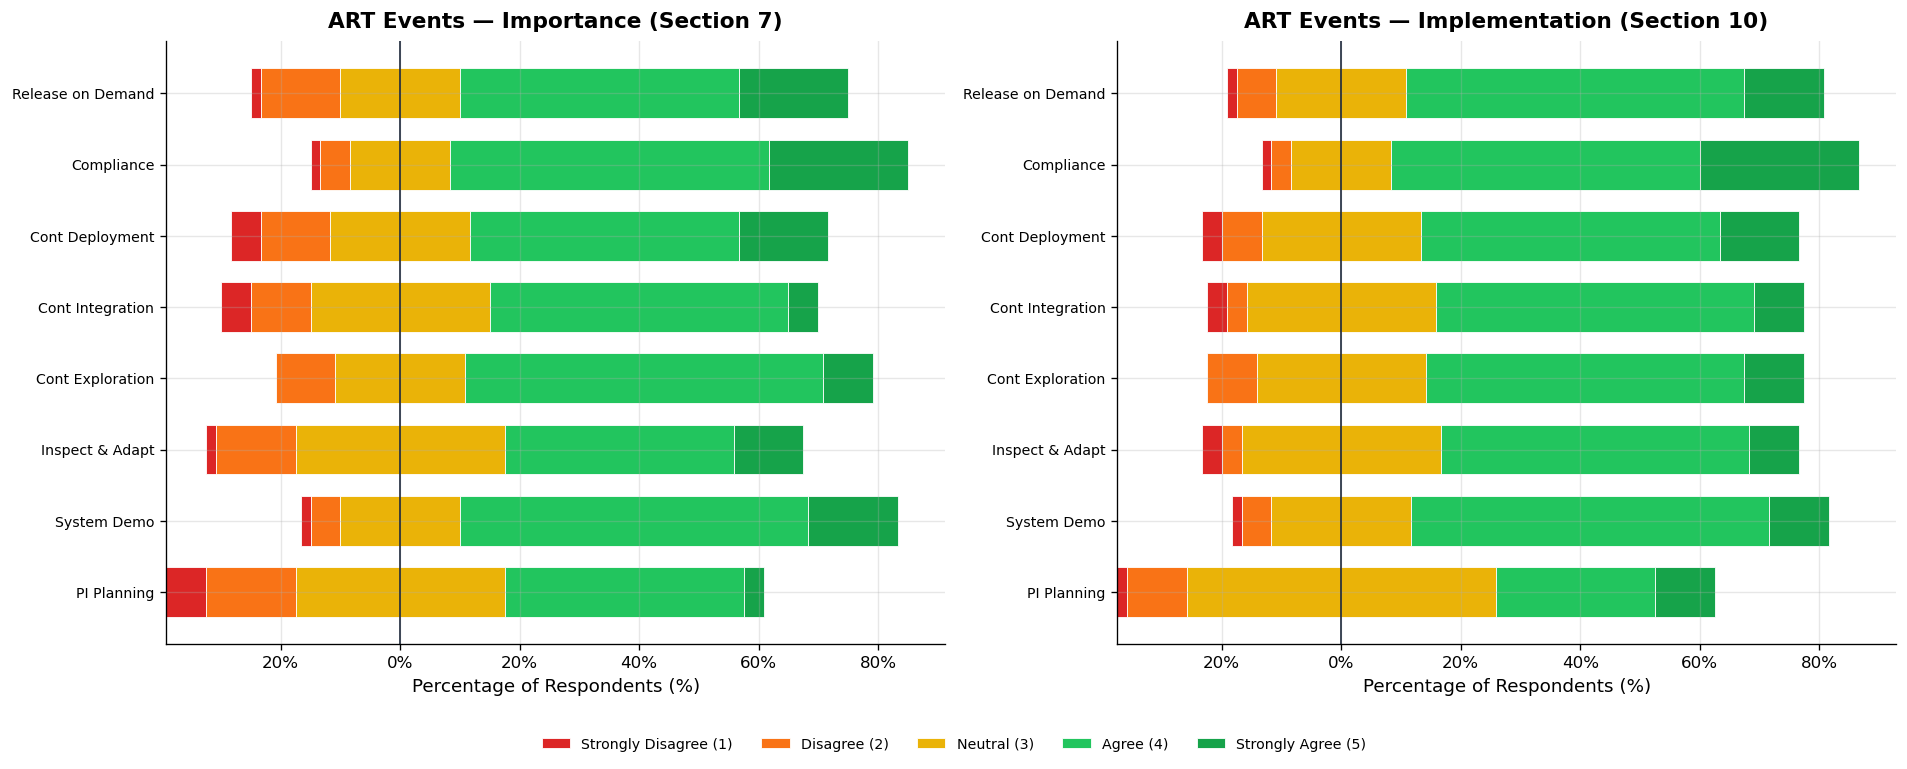

In [32]:
# ── ART Importance vs Implementation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

p7_cols   = [c for c in scale_cols if c.startswith('p7')]
p7_labels = ['PI Planning','System Demo','Inspect & Adapt','Cont Exploration',
             'Cont Integration','Cont Deployment','Compliance','Release on Demand']
likert_diverging(axes[0], p7_cols, 'ART Events — Importance (Section 7)', p7_labels)

i10_cols   = [c for c in scale_cols if c.startswith('i10')]
i10_labels = ['PI Planning','System Demo','Inspect & Adapt','Cont Exploration',
              'Cont Integration','Cont Deployment','Compliance','Release on Demand']
likert_diverging(axes[1], i10_cols, 'ART Events — Implementation (Section 10)', i10_labels)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=5, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.07), frameon=False)
plt.tight_layout()
plt.savefig('fig_art_likert.png', bbox_inches='tight', dpi=150)
plt.show()

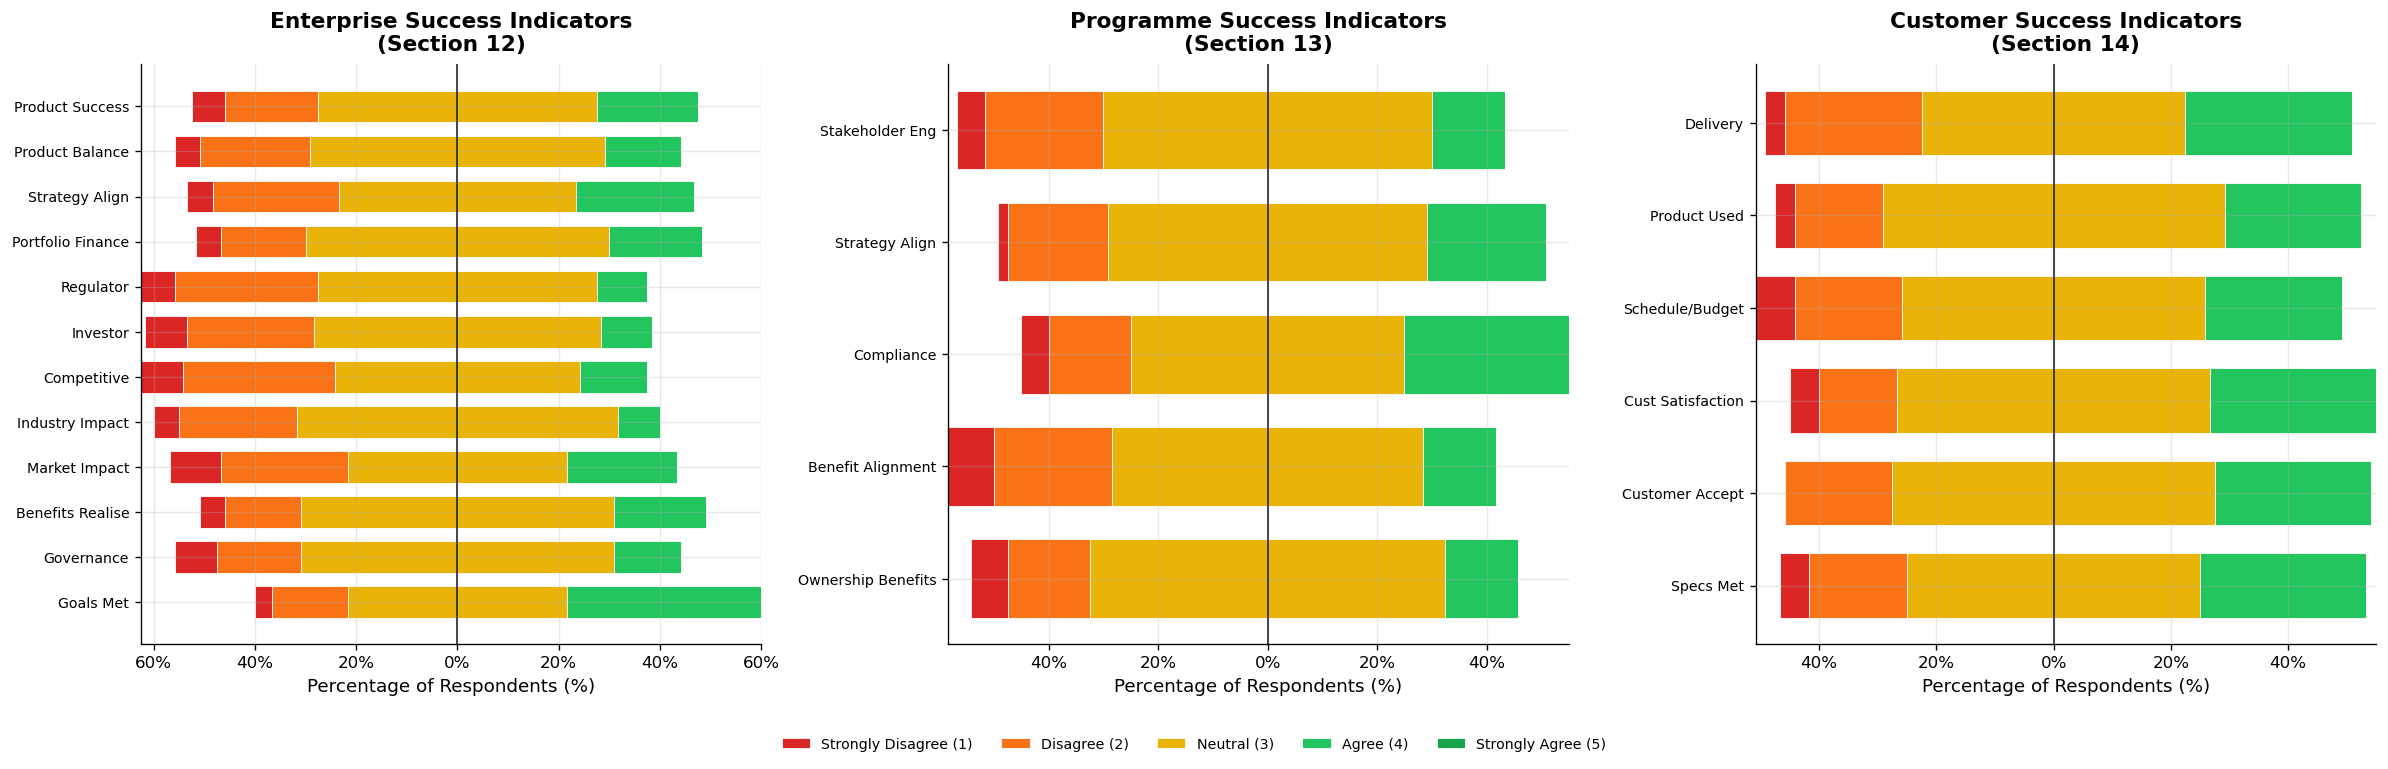

In [33]:
# ── Success Indicators ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

s12_cols   = [c for c in scale_cols if c.startswith('s12')]
s12_labels = ['Goals Met','Governance','Benefits Realise','Market Impact',
              'Industry Impact','Competitive','Investor','Regulator',
              'Portfolio Finance','Strategy Align','Product Balance','Product Success']
likert_diverging(axes[0], s12_cols, 'Enterprise Success Indicators\n(Section 12)', s12_labels)

s13_cols   = [c for c in scale_cols if c.startswith('s13')]
s13_labels = ['Ownership Benefits','Benefit Alignment','Compliance','Strategy Align','Stakeholder Eng']
likert_diverging(axes[1], s13_cols, 'Programme Success Indicators\n(Section 13)', s13_labels)

s14_cols   = [c for c in scale_cols if c.startswith('s14')]
s14_labels = ['Specs Met','Customer Accept','Cust Satisfaction','Schedule/Budget','Product Used','Delivery']
likert_diverging(axes[2], s14_cols, 'Customer Success Indicators\n(Section 14)', s14_labels)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=5, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.07), frameon=False)
plt.tight_layout()
plt.savefig('fig_success_likert.png', bbox_inches='tight', dpi=150)
plt.show()

## 7 — Importance vs Implementation Gap Analysis

**What's happening here? (This is one of the most important analyses!)**

This is where we directly compare what people think *should* be happening vs what *is* happening. 

**How to read the charts:**
- **Blue bars** = Importance score (Q6/7/8 — "how important is this?")
- **Purple bars** = Implementation score (Q9/10/11 — "is this actually being done?")
- **Arrows** show the direction and size of the gap:
  - 🔴 **Red arrow** = High gap (importance > implementation by more than 0.5 points) — this is a problem area where the organisation is falling short
  - ⚫ **Grey arrow** = Small/acceptable gap
  - 🟢 **Green arrow** = Reverse gap (implementation actually exceeds perceived importance — rare but positive)

**Why this matters:**  
If there's a big gap, it means the team *knows* something is important but isn't doing it. These gaps are the most actionable finding — they tell organisations exactly where to focus improvement efforts.

**The printed table** at the bottom shows exact numbers with a `⚠ HIGH GAP` flag on anything with a gap > 0.5.

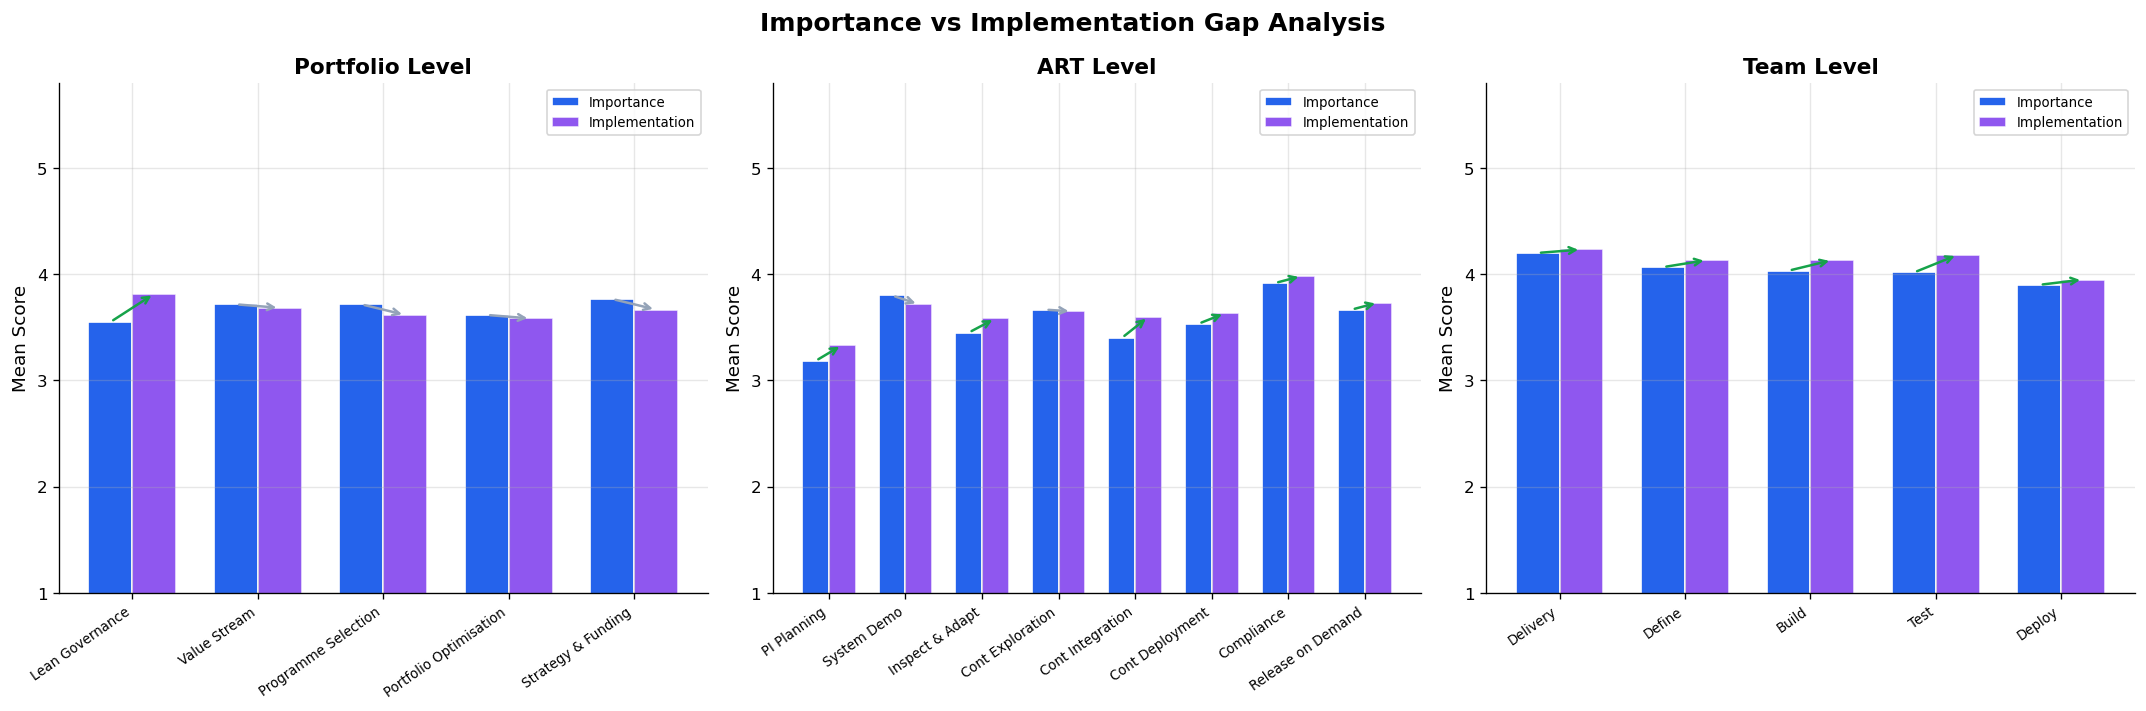


=== GAP SUMMARY (Importance − Implementation) ===

Portfolio Level:
  Lean Governance                Imp=3.55  Impl=3.82  Gap=-0.27 ✓
  Value Stream                   Imp=3.72  Impl=3.68  Gap=+0.03 ✓
  Programme Selection            Imp=3.72  Impl=3.62  Gap=+0.10 ✓
  Portfolio Optimisation         Imp=3.62  Impl=3.58  Gap=+0.03 ✓
  Strategy & Funding             Imp=3.77  Impl=3.67  Gap=+0.10 ✓

ART Level:
  PI Planning                    Imp=3.18  Impl=3.33  Gap=-0.15 ✓
  System Demo                    Imp=3.80  Impl=3.72  Gap=+0.08 ✓
  Inspect & Adapt                Imp=3.45  Impl=3.58  Gap=-0.13 ✓
  Cont Exploration               Imp=3.67  Impl=3.65  Gap=+0.02 ✓
  Cont Integration               Imp=3.40  Impl=3.60  Gap=-0.20 ✓
  Cont Deployment                Imp=3.53  Impl=3.63  Gap=-0.10 ✓
  Compliance                     Imp=3.92  Impl=3.98  Gap=-0.07 ✓
  Release on Demand              Imp=3.67  Impl=3.73  Gap=-0.07 ✓

Team Level:
  Delivery                       Imp=4.20  Impl=

In [34]:
# Portfolio gap
portfolio_importance    = ['p6_lean_gov_2','p6_value_stream','p6_prog_selection','p6_portfolio_opt','p6_strategy_funding']
portfolio_implementation= ['i9_lean_gov','i9_value_stream','i9_prog_selection','i9_portfolio_opt','i9_strategy_funding']
portfolio_labels        = ['Lean Governance','Value Stream','Programme Selection','Portfolio Optimisation','Strategy & Funding']

art_importance    = ['p7_pi_planning','p7_system_demo','p7_inspect_adapt','p7_cont_exploration',
                     'p7_cont_integration','p7_cont_deployment','p7_compliance','p7_release_demand']
art_implementation= ['i10_pi_planning','i10_system_demo','i10_inspect_adapt','i10_cont_exploration',
                     'i10_cont_integration','i10_cont_deployment','i10_compliance','i10_release_demand']
art_labels        = ['PI Planning','System Demo','Inspect & Adapt','Cont Exploration',
                     'Cont Integration','Cont Deployment','Compliance','Release on Demand']

team_importance    = ['p8_delivery','p8_define','p8_build','p8_test','p8_deploy']
team_implementation= ['i11_delivery','i11_define','i11_build','i11_test','i11_deploy']
team_labels        = ['Delivery','Define','Build','Test','Deploy']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Importance vs Implementation Gap Analysis', fontsize=15, fontweight='bold')

for ax, imp_cols, impl_cols, labels, title in [
    (axes[0], portfolio_importance, portfolio_implementation, portfolio_labels, 'Portfolio Level'),
    (axes[1], art_importance, art_implementation, art_labels, 'ART Level'),
    (axes[2], team_importance, team_implementation, team_labels, 'Team Level'),
]:
    imp_means  = df[imp_cols].mean().values
    impl_means = df[impl_cols].mean().values
    gaps       = imp_means - impl_means

    x = np.arange(len(labels))
    w = 0.35
    b1 = ax.bar(x - w/2, imp_means,  w, label='Importance',     color='#2563EB', edgecolor='white')
    b2 = ax.bar(x + w/2, impl_means, w, label='Implementation', color='#7C3AED', edgecolor='white', alpha=0.85)

    for i, gap in enumerate(gaps):
        color = '#DC2626' if gap > 0.5 else '#16A34A' if gap < 0 else '#94A3B8'
        ax.annotate('', xy=(x[i]+w/2, impl_means[i]), xytext=(x[i]-w/2, imp_means[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(1, 5.8)
    ax.set_ylabel('Mean Score')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_gap_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Print gap summary
print('\n=== GAP SUMMARY (Importance − Implementation) ===')
for level, imp_cols, impl_cols, labels in [
    ('Portfolio', portfolio_importance, portfolio_implementation, portfolio_labels),
    ('ART',       art_importance,       art_implementation,       art_labels),
    ('Team',      team_importance,      team_implementation,      team_labels),
]:
    print(f'\n{level} Level:')
    for lbl, ic, imc in zip(labels, imp_cols, impl_cols):
        imp  = df[ic].mean()
        impl = df[imc].mean()
        gap  = imp - impl
        flag = ' ⚠ HIGH GAP' if gap > 0.5 else ' ✓' if gap <= 0.2 else ''
        print(f'  {lbl:<30} Imp={imp:.2f}  Impl={impl:.2f}  Gap={gap:+.2f}{flag}')

## 8 — Correlation Analysis

**What's happening here?**  
A **correlation** measures how closely two variables move together. If question A and question B are correlated, it means people who scored A highly also tended to score B highly (or vice versa).

**How correlation is measured (Pearson r):**
- **r = +1.0** = perfect positive correlation — if you score one high, you score the other high too
- **r = 0.0** = no relationship at all
- **r = -1.0** = perfect negative correlation — if you score one high, the other goes low

**General rules of thumb:**
- |r| > 0.7 = strong correlation
- |r| 0.4–0.7 = moderate correlation
- |r| < 0.4 = weak correlation

**The three charts:**
1. **Full correlation matrix** — every question vs every other question. Dark red = strong positive correlation, dark blue = strong negative. This is the "bird's eye view."
2. **Top 15 strongest pairs** — the 15 question pairs with the highest correlation coefficients, ranked. Makes it easy to spot the most tightly linked survey items.
3. **Section-level correlation matrix** — instead of looking at individual questions, we average each section and see how the 9 sections correlate with each other. This tells us whether, for example, people who rate ART-level practices highly also tend to rate success indicators highly.

**Why this matters:**  
Strong correlations between *implementation* sections and *success* sections would be the strongest evidence that doing those practices actually leads to better outcomes.

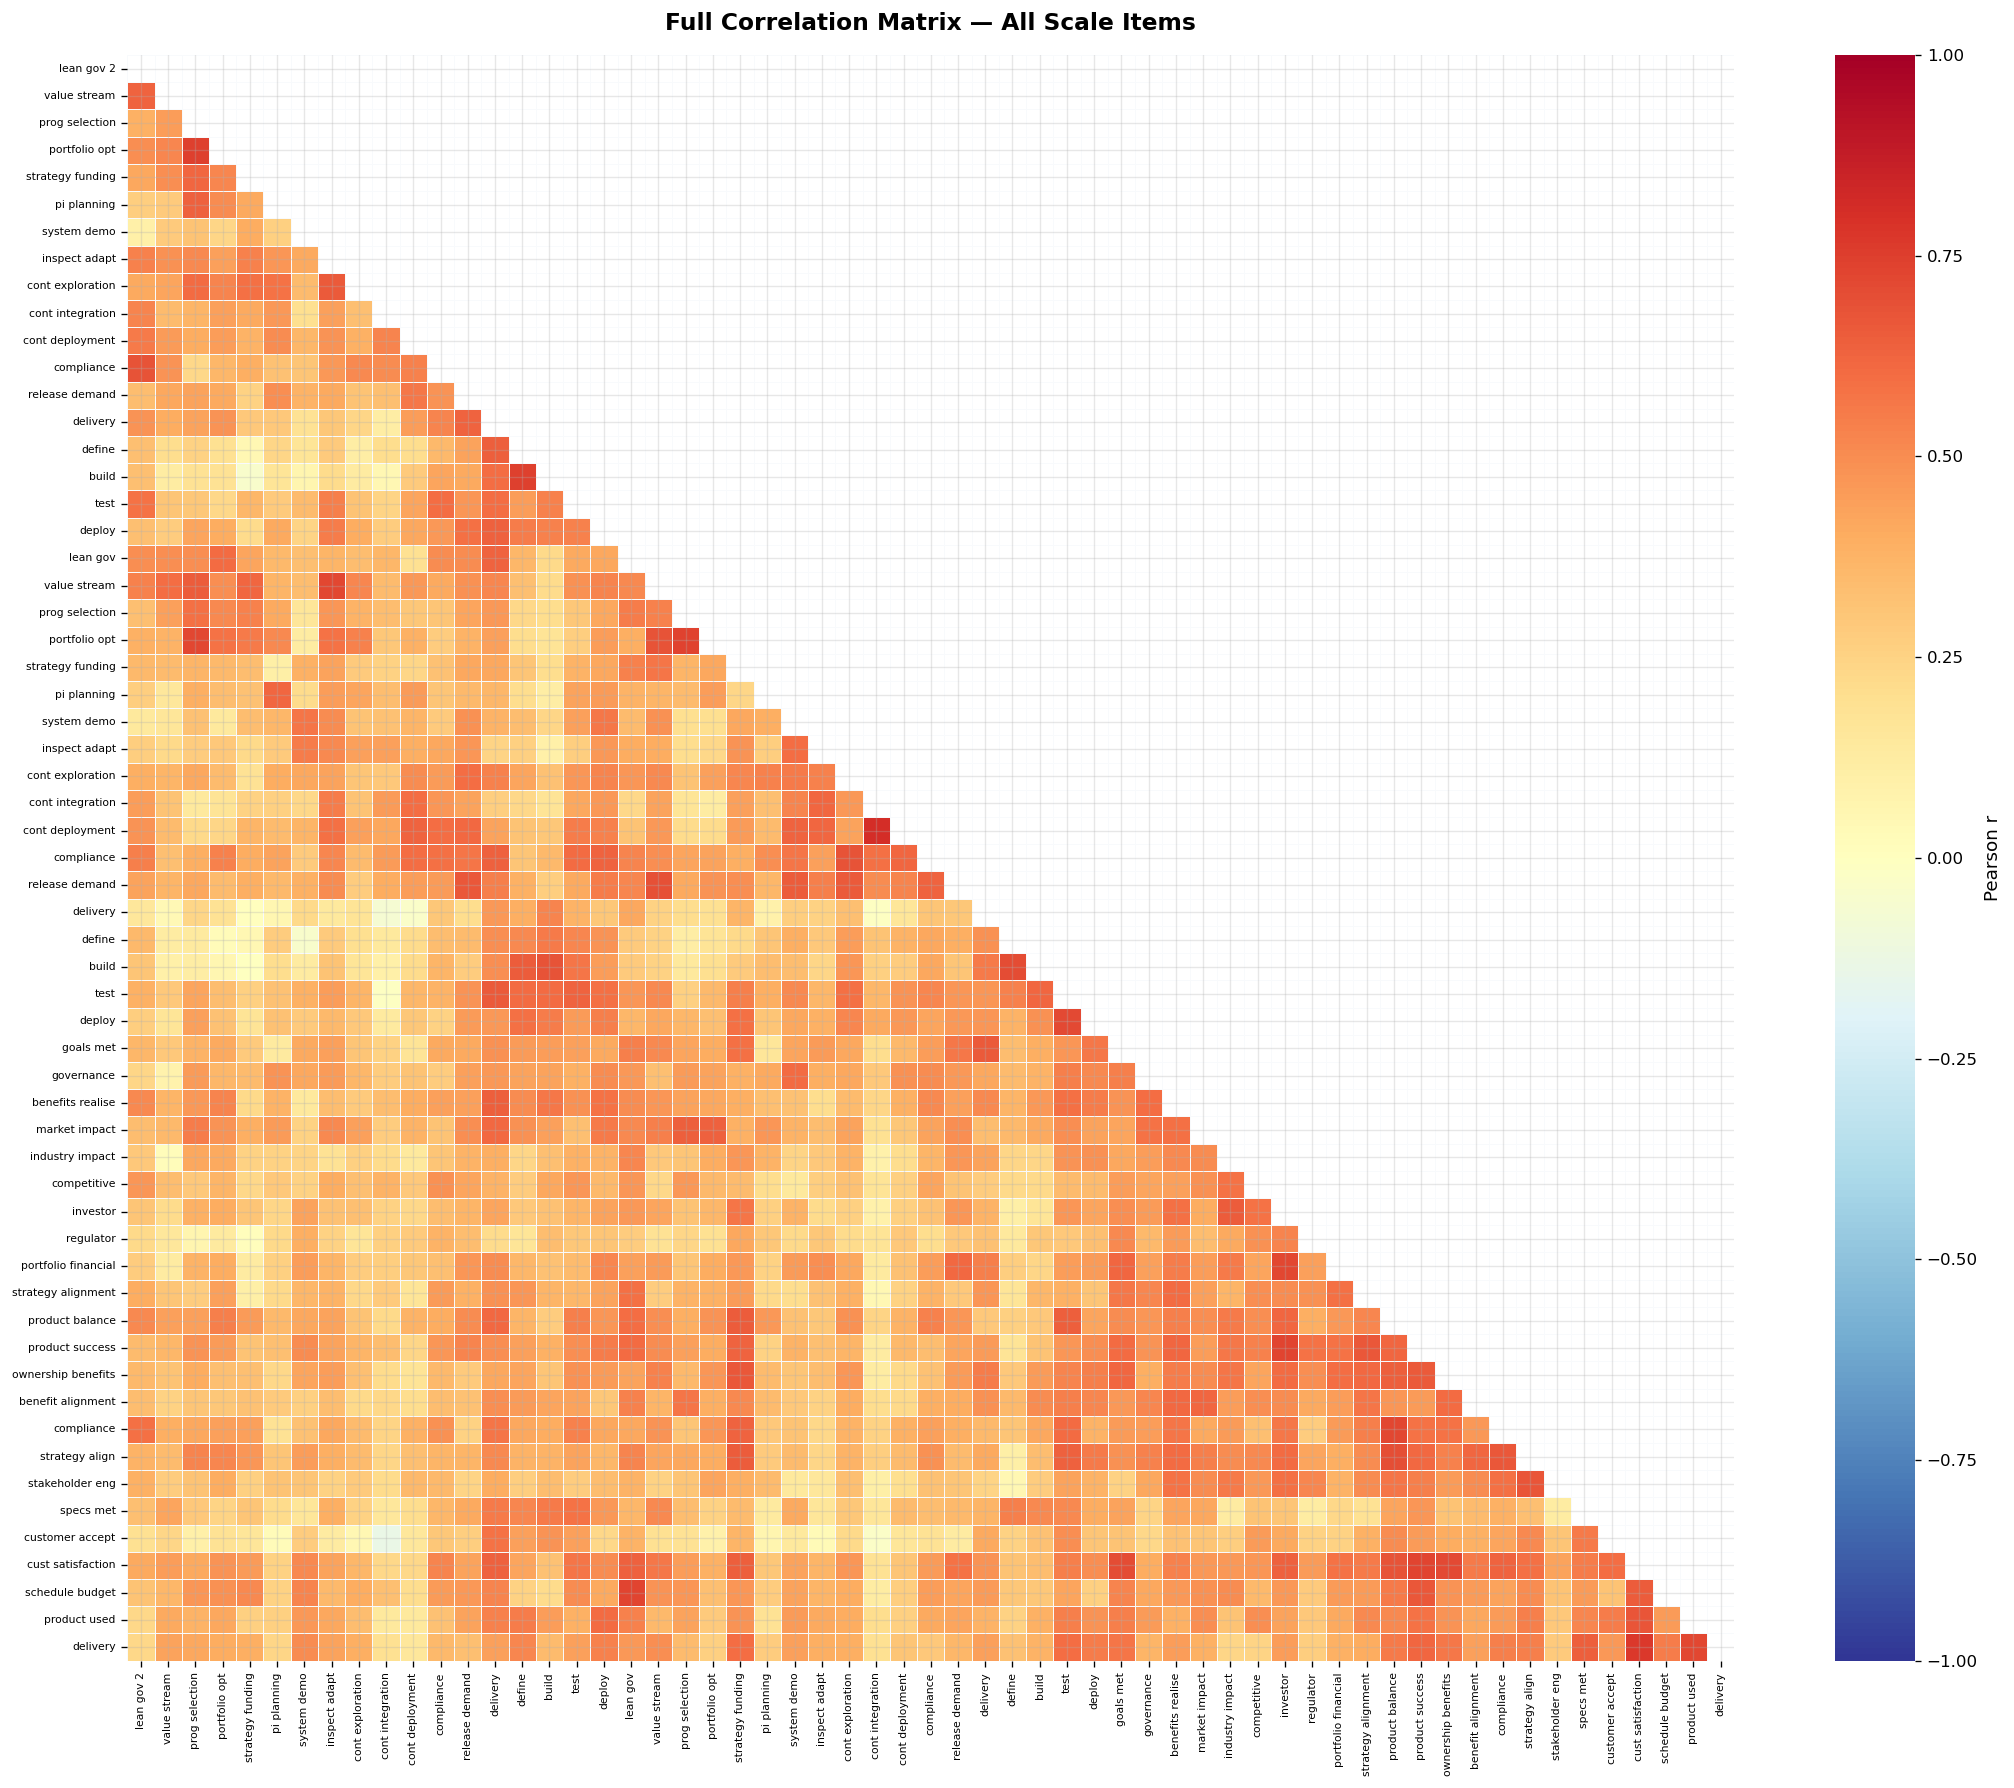

In [35]:
# Full correlation heatmap
corr = df[scale_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor='#F8FAFC',
            annot=False, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Full Correlation Matrix — All Scale Items', fontsize=14, fontweight='bold', pad=15)

short = [c.replace('p6_','').replace('p7_','').replace('p8_','').replace('i9_','').replace('i10_','').replace('i11_','').replace('s12_','').replace('s13_','').replace('s14_','').replace('_',' ') for c in scale_cols]
ax.set_xticklabels(short, rotation=90, fontsize=6.5)
ax.set_yticklabels(short, rotation=0, fontsize=6.5)

plt.tight_layout()
plt.savefig('fig_full_corr.png', bbox_inches='tight', dpi=150)
plt.show()

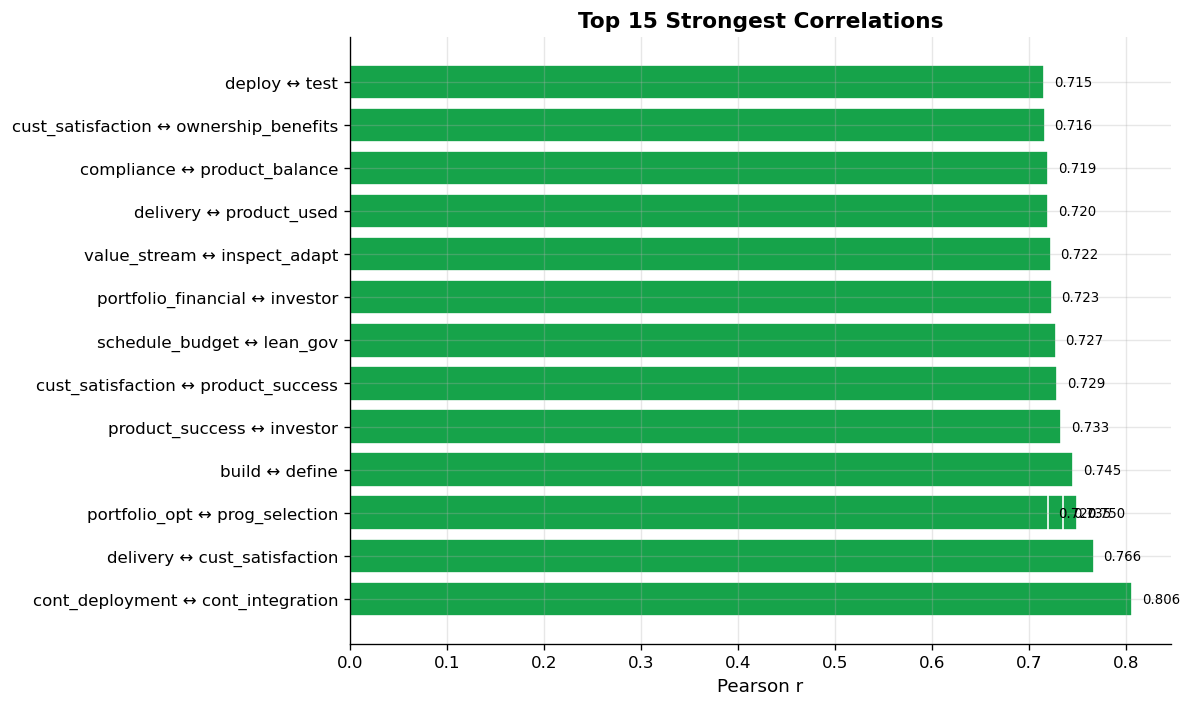

In [36]:
# Top 15 strongest correlations (excluding self)
corr_pairs = (corr.where(~mask)
               .stack()
               .reset_index()
               .rename(columns={'level_0':'Var1','level_1':'Var2',0:'r'}))
corr_pairs['abs_r'] = corr_pairs['r'].abs()
top15 = corr_pairs.nlargest(15, 'abs_r')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#16A34A' if r > 0 else '#DC2626' for r in top15['r']]
bars = ax.barh(
    [f"{a.split('_',1)[-1]} ↔ {b.split('_',1)[-1]}" for a, b in zip(top15['Var1'], top15['Var2'])],
    top15['r'], color=colors, edgecolor='white'
)
ax.axvline(0, color='#1E293B', linewidth=1)
ax.set_xlabel('Pearson r')
ax.set_title('Top 15 Strongest Correlations', fontweight='bold')
for bar, val in zip(bars, top15['r']):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('fig_top_corr.png', bbox_inches='tight', dpi=150)
plt.show()

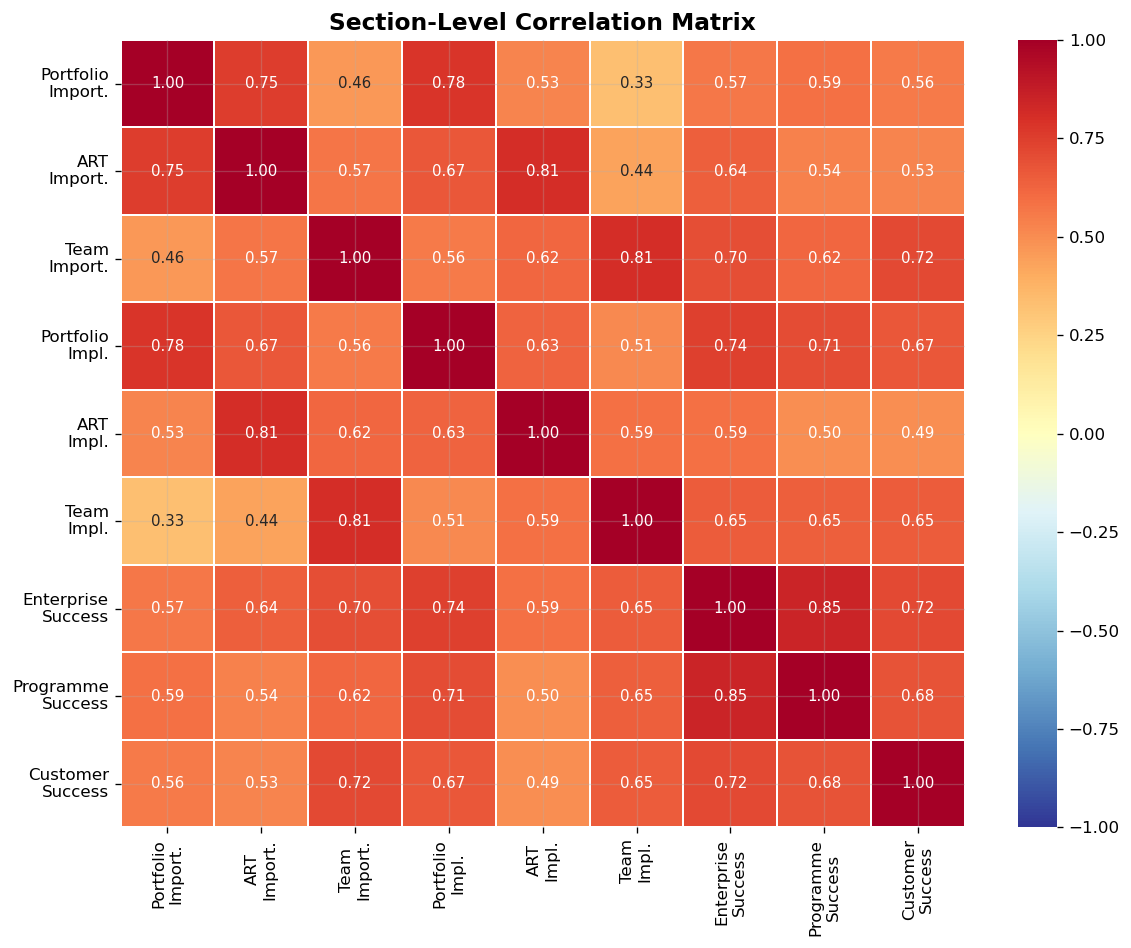

In [37]:
# Cross-section correlation heatmap (section averages)
section_avgs = pd.DataFrame({
    'Portfolio\nImport.':  df[[c for c in scale_cols if c.startswith('p6')]].mean(axis=1),
    'ART\nImport.':        df[[c for c in scale_cols if c.startswith('p7')]].mean(axis=1),
    'Team\nImport.':       df[[c for c in scale_cols if c.startswith('p8')]].mean(axis=1),
    'Portfolio\nImpl.':    df[[c for c in scale_cols if c.startswith('i9')]].mean(axis=1),
    'ART\nImpl.':          df[[c for c in scale_cols if c.startswith('i10')]].mean(axis=1),
    'Team\nImpl.':         df[[c for c in scale_cols if c.startswith('i11')]].mean(axis=1),
    'Enterprise\nSuccess': df[[c for c in scale_cols if c.startswith('s12')]].mean(axis=1),
    'Programme\nSuccess':  df[[c for c in scale_cols if c.startswith('s13')]].mean(axis=1),
    'Customer\nSuccess':   df[[c for c in scale_cols if c.startswith('s14')]].mean(axis=1),
})

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(section_avgs.corr(), annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Section-Level Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_section_corr.png', bbox_inches='tight', dpi=150)
plt.show()

## 9 — Score Distribution by Section

**What's happening here?**  
We're looking at the **shape** of the responses for each section — not just the average, but the full spread of how people answered.

**How to read these charts:**
- The X-axis shows the 5 possible scores (1, 2, 3, 4, 5)
- The Y-axis shows what **percentage** of responses fell on each score
- The **dashed line** shows the mean (average) for that section

**Why look at distributions and not just the mean?**  
The average can be misleading. For example, a mean of 3.0 could mean:
- Everyone gave a 3 (very consistent, neutral opinion), OR
- Half the people gave 1 and half gave 5 (extreme disagreement!)

By looking at the shape, we can tell whether respondents generally agreed with each other (tall narrow bar at one score) or were spread out (bars spread across 1–5).

**Sections with bars skewed right (towards 4–5)** = positive consensus — people agree this matters or is happening  
**Sections with bars skewed left (towards 1–2)** = negative consensus  
**Sections with a flat or spread distribution** = mixed opinions, no consensus

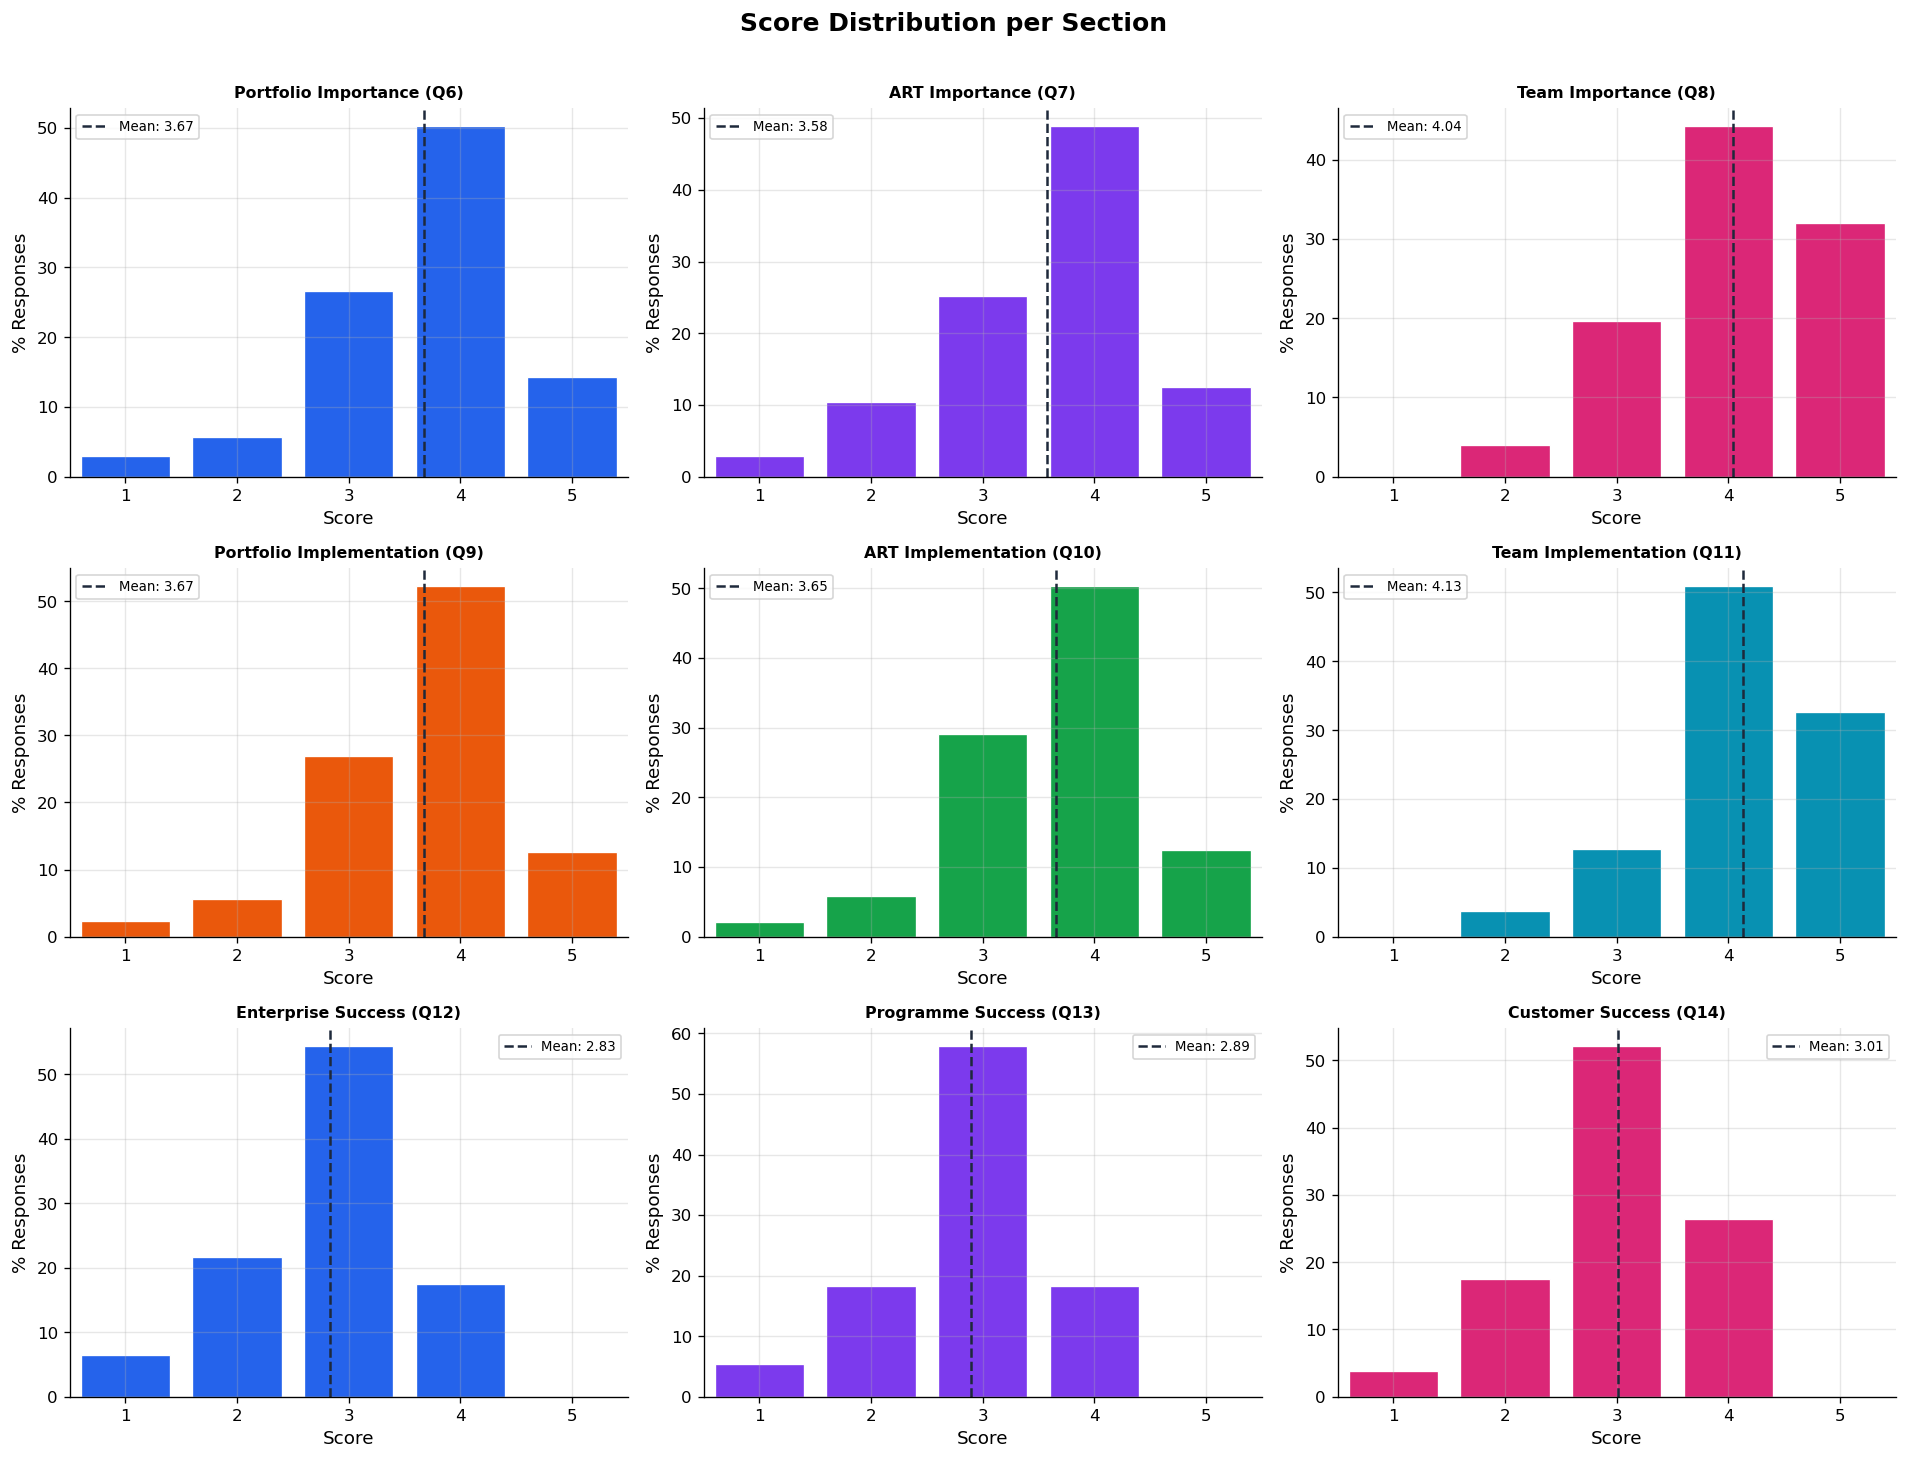

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Score Distribution per Section', fontsize=15, fontweight='bold', y=1.01)

sec_info = [
    ('Portfolio Importance (Q6)',    [c for c in scale_cols if c.startswith('p6')],  PALETTE[0]),
    ('ART Importance (Q7)',          [c for c in scale_cols if c.startswith('p7')],  PALETTE[1]),
    ('Team Importance (Q8)',         [c for c in scale_cols if c.startswith('p8')],  PALETTE[2]),
    ('Portfolio Implementation (Q9)',[c for c in scale_cols if c.startswith('i9')],  PALETTE[3]),
    ('ART Implementation (Q10)',     [c for c in scale_cols if c.startswith('i10')], PALETTE[4]),
    ('Team Implementation (Q11)',    [c for c in scale_cols if c.startswith('i11')], PALETTE[5]),
    ('Enterprise Success (Q12)',     [c for c in scale_cols if c.startswith('s12')], PALETTE[0]),
    ('Programme Success (Q13)',      [c for c in scale_cols if c.startswith('s13')], PALETTE[1]),
    ('Customer Success (Q14)',       [c for c in scale_cols if c.startswith('s14')], PALETTE[2]),
]

for ax, (title, cols, color) in zip(axes.flat, sec_info):
    values = df[cols].values.flatten()
    counts = pd.Series(values).value_counts().sort_index()
    ax.bar(counts.index, counts.values / counts.sum() * 100,
           color=color, edgecolor='white', linewidth=0.8)
    ax.axvline(np.mean(values), color='#1E293B', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(values):.2f}')
    ax.set_xlim(0.5, 5.5)
    ax.set_xticks([1,2,3,4,5])
    ax.set_xlabel('Score')
    ax.set_ylabel('% Responses')
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 10 — Does Experience Level Matter? (Subgroup Analysis)

**What's happening here?**  
We're asking: **do people with more Agile experience rate things differently?** This is a subgroup analysis — we split respondents into groups by experience level and compare their scores.

**The heatmap** shows each experience group (rows) vs each survey section (columns). Darker/warmer colours = higher scores. If you see a clear pattern from top to bottom (e.g., scores increase as experience increases), it suggests experience changes how people perceive these practices.

**The ANOVA test (violin plot):**  
ANOVA = Analysis of Variance. It's a statistical test that checks whether the differences between groups are **real** or just random chance.

- **p < 0.05** = the difference IS statistically significant (less than 5% chance it's random) — we should pay attention to this
- **p ≥ 0.05** = the difference is NOT significant — it could just be random variation

The violin plot shows the **distribution** of overall success scores for each experience group. The wider the violin at a score, the more people gave that score. The box inside shows the median and interquartile range.

**Why this matters:**  
If experienced practitioners rate things very differently from beginners, it might mean there's a learning curve — newcomers don't yet appreciate certain practices that veterans know are critical.

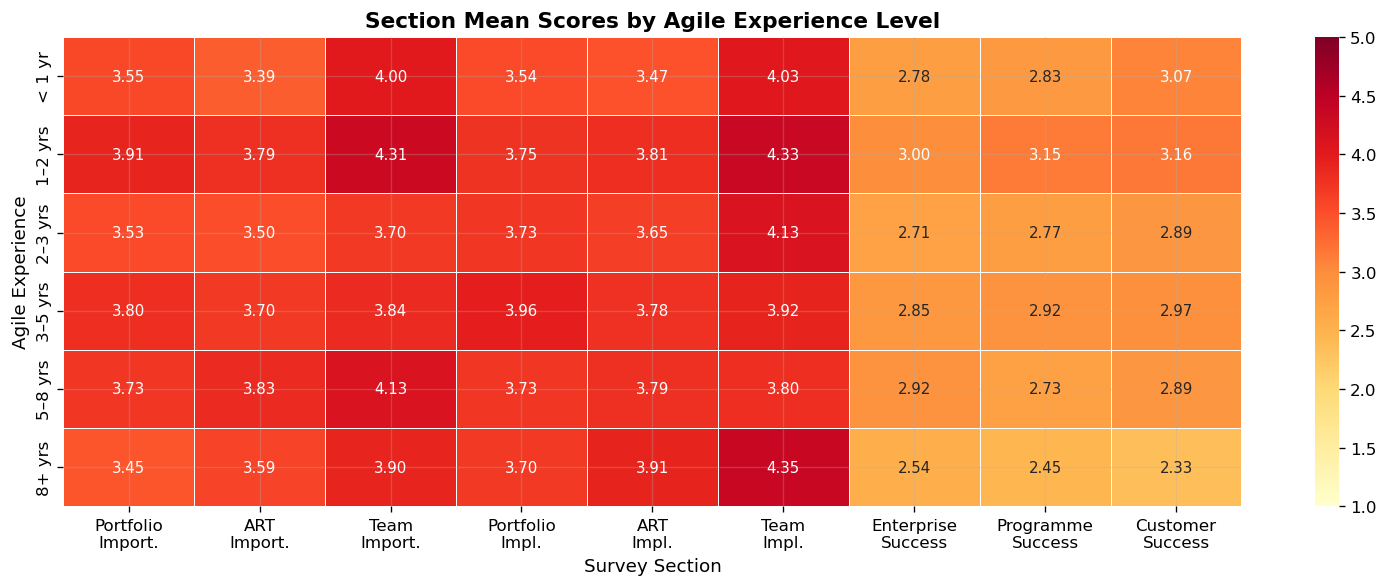

In [39]:
# Group by Agile experience and compare section means
exp_order = ['< 1 yr','1–2 yrs','2–3 yrs','3–5 yrs','5–8 yrs','8+ yrs']
present_exp = [e for e in exp_order if e in df['agile_exp_label'].values]

section_cols = {
    'Portfolio\nImport.': [c for c in scale_cols if c.startswith('p6')],
    'ART\nImport.':       [c for c in scale_cols if c.startswith('p7')],
    'Team\nImport.':      [c for c in scale_cols if c.startswith('p8')],
    'Portfolio\nImpl.':   [c for c in scale_cols if c.startswith('i9')],
    'ART\nImpl.':         [c for c in scale_cols if c.startswith('i10')],
    'Team\nImpl.':        [c for c in scale_cols if c.startswith('i11')],
    'Enterprise\nSuccess':df[[c for c in scale_cols if c.startswith('s12')]].columns.tolist(),
    'Programme\nSuccess': df[[c for c in scale_cols if c.startswith('s13')]].columns.tolist(),
    'Customer\nSuccess':  df[[c for c in scale_cols if c.startswith('s14')]].columns.tolist(),
}

heatmap_data = pd.DataFrame(index=present_exp, columns=list(section_cols.keys()), dtype=float)
for exp in present_exp:
    subset = df[df['agile_exp_label'] == exp]
    for sec, cols in section_cols.items():
        heatmap_data.loc[exp, sec] = subset[cols].mean().mean()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=1, vmax=5,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Section Mean Scores by Agile Experience Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Survey Section')
ax.set_ylabel('Agile Experience')
plt.tight_layout()
plt.savefig('fig_exp_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

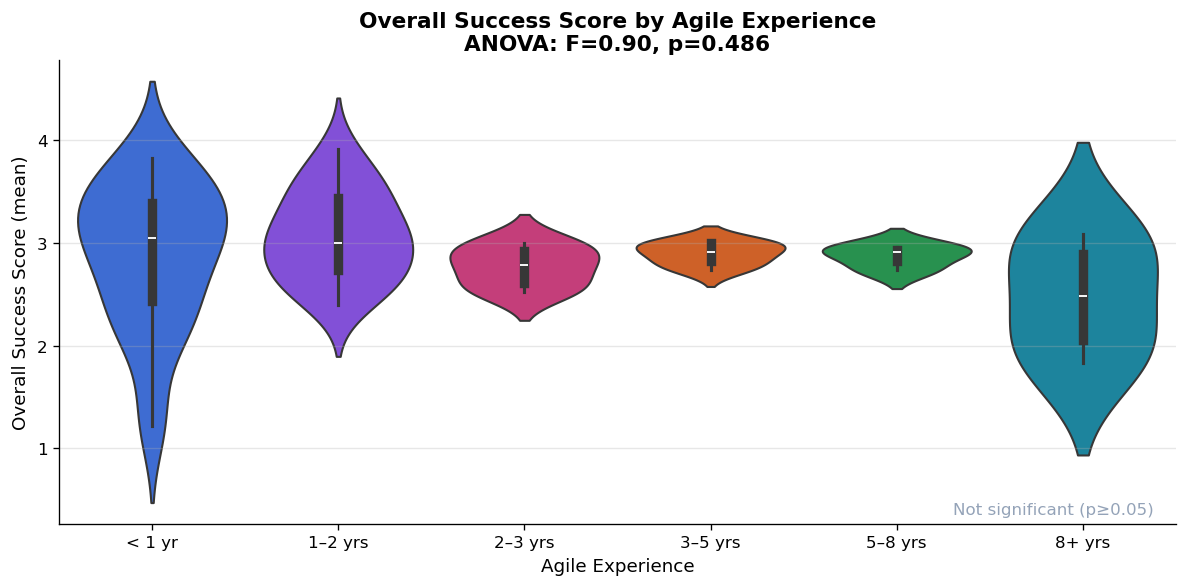

In [40]:
# ANOVA: Does experience level significantly affect overall success scores?
success_cols = [c for c in scale_cols if c.startswith(('s12','s13','s14'))]
df['overall_success'] = df[success_cols].mean(axis=1)

groups = [df[df['agile_exp_label'] == exp]['overall_success'].dropna().values
          for exp in present_exp]
f_stat, p_val = stats.f_oneway(*[g for g in groups if len(g) > 0])

fig, ax = plt.subplots(figsize=(10, 5))
df_box = df[df['agile_exp_label'].isin(present_exp)]
order_present = [e for e in exp_order if e in df_box['agile_exp_label'].values]

sns.violinplot(data=df_box, x='agile_exp_label', y='overall_success',
               order=order_present, palette=PALETTE, inner='box', ax=ax)
ax.set_xlabel('Agile Experience')
ax.set_ylabel('Overall Success Score (mean)')
ax.set_title(f'Overall Success Score by Agile Experience\nANOVA: F={f_stat:.2f}, p={p_val:.3f}',
             fontweight='bold')
sig_text = '*** Significant (p<0.05)' if p_val < 0.05 else 'Not significant (p≥0.05)'
ax.text(0.98, 0.02, sig_text, transform=ax.transAxes, ha='right', fontsize=10,
        color='#DC2626' if p_val < 0.05 else '#94A3B8')
plt.tight_layout()
plt.savefig('fig_anova_exp.png', bbox_inches='tight', dpi=150)
plt.show()

## 11 — Does Your Role Matter? (Role-Based Analysis)

**What's happening here?**  
Similar to the experience analysis, here we split respondents by **job role** and compare how each role rates the different survey sections. 

The heatmap shows role (rows) vs section (columns). Deeper blue = higher score.

**Why this is interesting:**  
Different roles have very different relationships with Agile processes:
- A **Scrum Master** spends every day running sprints and ceremonies — they'll have a very formed opinion on ART-level events
- A **Portfolio Manager** is focused on strategy and funding — they'll likely rate portfolio-level governance differently
- A **Developer** cares most about team-level build/test/deploy capabilities

If certain roles consistently score specific sections higher or lower, it reveals where there are **perspective gaps** in the organisation — which can cause conflict if different stakeholders have very different ideas of what success looks like.

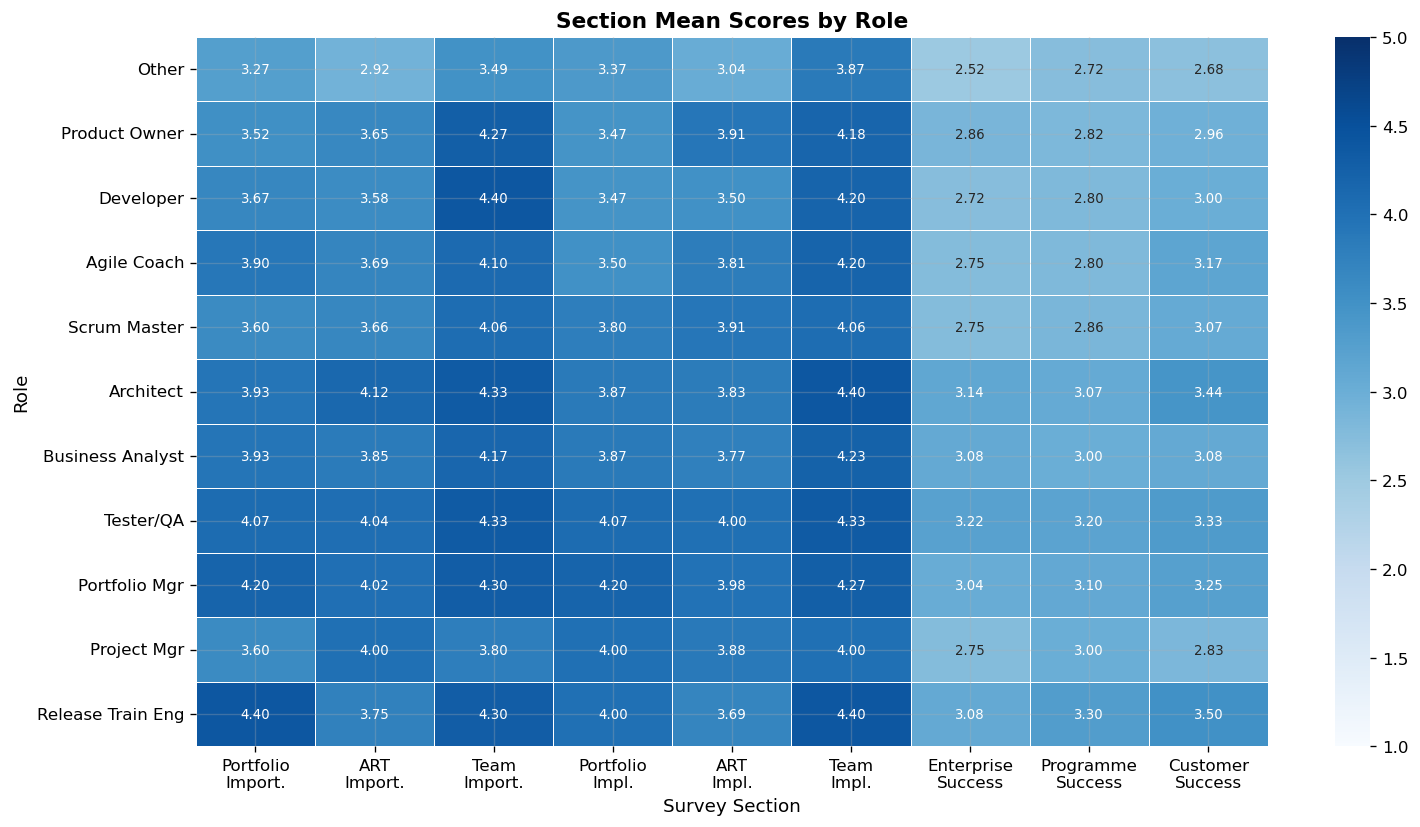

In [41]:
role_section_data = []
for role in df['role_label'].dropna().unique():
    subset = df[df['role_label'] == role]
    row = {'Role': role, 'n': len(subset)}
    for sec, cols in section_cols.items():
        row[sec] = subset[cols].mean().mean()
    row['Overall Success'] = subset[success_cols].mean().mean()
    role_section_data.append(row)

role_df = pd.DataFrame(role_section_data).set_index('Role')

fig, ax = plt.subplots(figsize=(13, 7))
sec_plot_cols = [c for c in role_df.columns if c not in ['n', 'Overall Success']]
sns.heatmap(role_df[sec_plot_cols].astype(float), annot=True, fmt='.2f',
            cmap='Blues', vmin=1, vmax=5,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Section Mean Scores by Role', fontsize=13, fontweight='bold')
ax.set_xlabel('Survey Section')
ax.set_ylabel('Role')
plt.tight_layout()
plt.savefig('fig_role_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 12 — Best and Worst Rated Items

**What's happening here?**  
We rank every single survey question by its average score and pull out the top 10 and bottom 10. This gives us the clearest possible view of what respondents value most vs. least.

- 🟢 **Top 10** (green) = the highest-scoring practices/success indicators — things people strongly agree with
- 🔴 **Bottom 10** (red) = the lowest-scoring items — areas where respondents are uncertain, disagree, or don't see as important

**Why this matters for the research:**  
The top items should form the core of the conceptual framework — if nearly everyone agrees these are important and happening, they're strong candidates for "key success factors." The bottom items might be things that need better awareness, investment, or rethinking in the context of Scaled Agile.

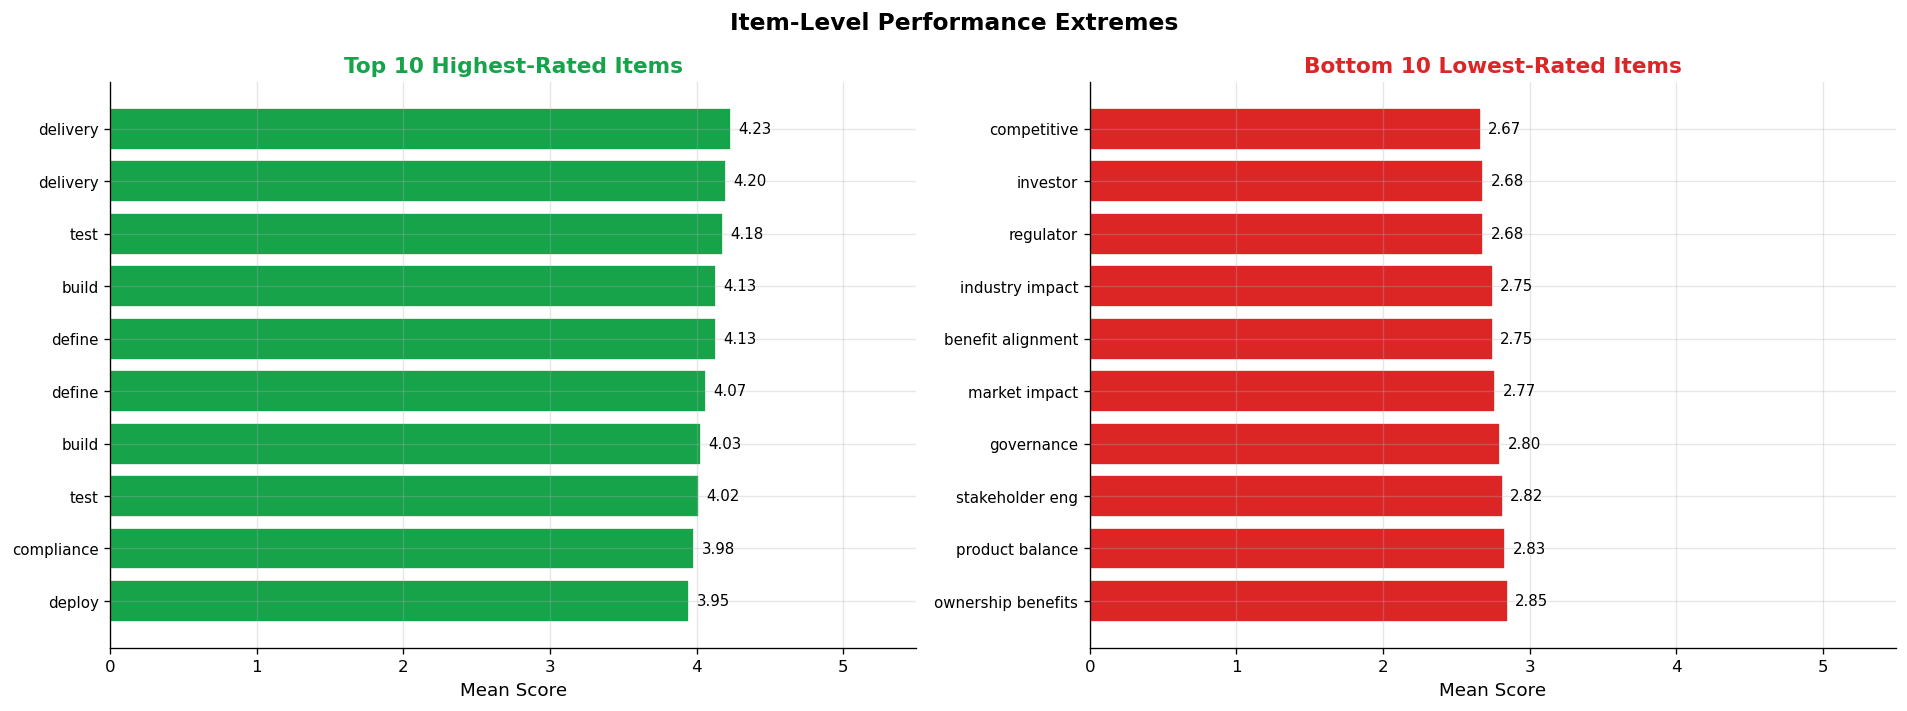

In [42]:
item_means = df[scale_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = item_means.head(10)
axes[0].barh(range(len(top10)),
             top10.values[::-1],
             color='#16A34A', edgecolor='white')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([c.split('_',1)[-1].replace('_',' ') for c in top10.index[::-1]], fontsize=9)
axes[0].set_xlabel('Mean Score')
axes[0].set_title('Top 10 Highest-Rated Items', fontweight='bold', color='#16A34A')
axes[0].set_xlim(0, 5.5)
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v+0.05, i, f'{v:.2f}', va='center', fontsize=9)

bot10 = item_means.tail(10)
axes[1].barh(range(len(bot10)),
             bot10.values,
             color='#DC2626', edgecolor='white')
axes[1].set_yticks(range(len(bot10)))
axes[1].set_yticklabels([c.split('_',1)[-1].replace('_',' ') for c in bot10.index], fontsize=9)
axes[1].set_xlabel('Mean Score')
axes[1].set_title('Bottom 10 Lowest-Rated Items', fontweight='bold', color='#DC2626')
axes[1].set_xlim(0, 5.5)
for i, v in enumerate(bot10.values):
    axes[1].text(v+0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Item-Level Performance Extremes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_bottom.png', bbox_inches='tight', dpi=150)
plt.show()

## 13 — Radar Chart (Spider Chart)

**What's happening here?**  
A radar chart (also called a spider chart) displays multiple variables on a circular chart, making it easy to see the overall "shape" of the data at a glance.

**How to read it:**
- Each "spoke" of the spider = one survey section
- The **further from the centre**, the higher the score (scale is 1–5)
- The **blue shaded area** = the actual scores
- The **red dashed circle** = the neutral line (score = 3.0)
- If a spoke reaches beyond the red circle, that section scored above neutral

**What a strong vs weak shape looks like:**  
- A large, full shape = high scores across all sections — a well-performing organisation
- A lopsided shape = some sections are much stronger than others — imbalanced capabilities
- Any spokes that dip inside the red circle = areas scoring below neutral — needs attention

This is a great summary chart for presentations because it communicates the overall picture immediately, without needing to read a table of numbers.

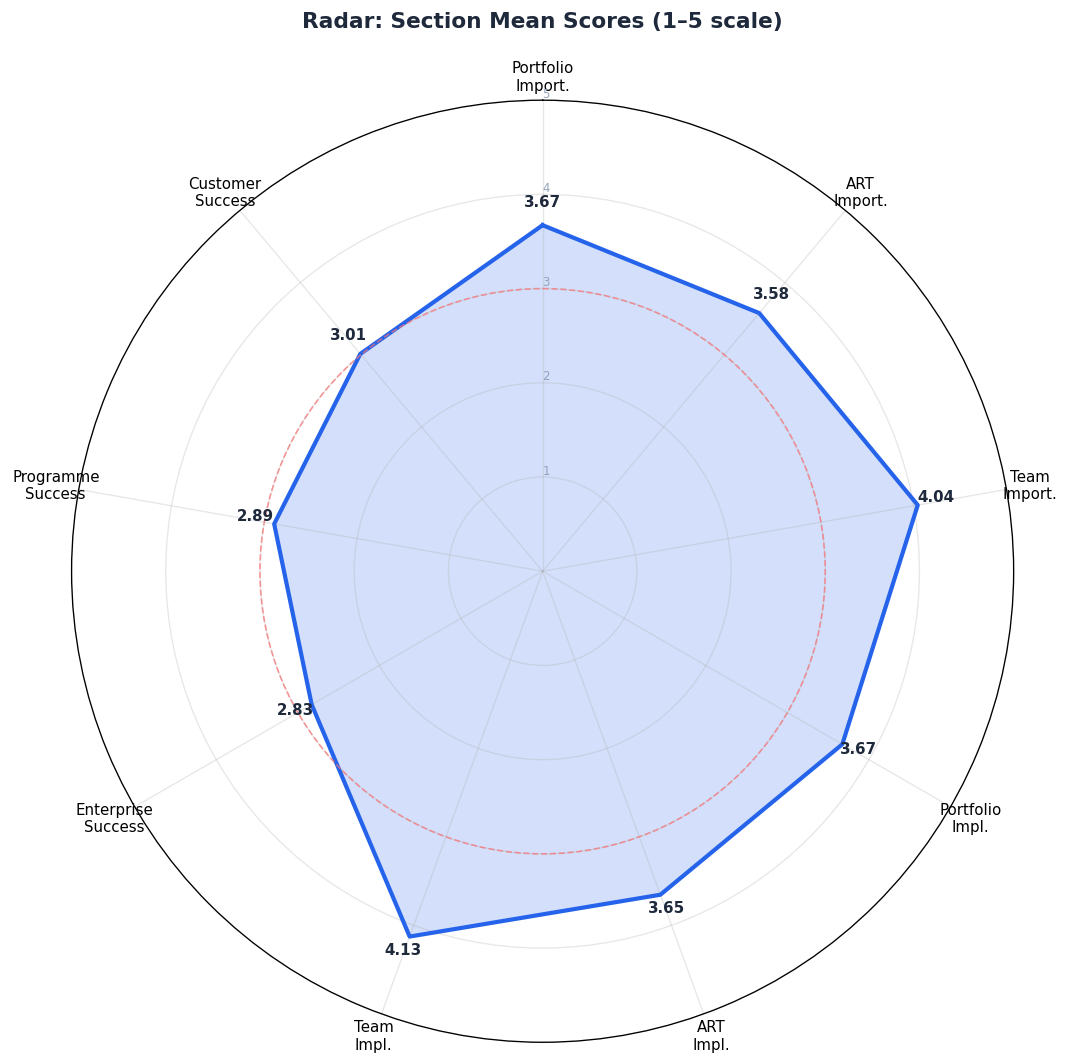

In [43]:
from matplotlib.patches import FancyArrowPatch

categories = ['Portfolio\nImport.','ART\nImport.','Team\nImport.',
              'Portfolio\nImpl.','ART\nImpl.','Team\nImpl.',
              'Enterprise\nSuccess','Programme\nSuccess','Customer\nSuccess']
N = len(categories)

values_all = [section_avgs[c].mean() for c in categories]
values_all += values_all[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=9)
ax.set_rlabel_position(0)
plt.yticks([1,2,3,4,5], ['1','2','3','4','5'], color='#94A3B8', size=7)
plt.ylim(0, 5)

ax.plot(angles, values_all, linewidth=2.5, linestyle='solid', color='#2563EB')
ax.fill(angles, values_all, alpha=0.2, color='#2563EB')
ax.axhline(3, color='#F87171', linestyle='--', linewidth=1, alpha=0.7)

for angle, value in zip(angles[:-1], values_all[:-1]):
    ax.text(angle, value + 0.2, f'{value:.2f}', ha='center', fontsize=9, color='#1E293B', fontweight='bold')

ax.set_title('Radar: Section Mean Scores (1–5 scale)', fontsize=13, fontweight='bold',
             pad=20, color='#1E293B')

plt.tight_layout()
plt.savefig('fig_radar.png', bbox_inches='tight', dpi=150)
plt.show()

## 14 — Survey Reliability (Cronbach's Alpha)

**What's happening here?**  
This is a check on whether the survey itself was well-designed. Specifically, we're asking: *"did questions within the same section actually measure the same thing?"*

**What is Cronbach's Alpha?**  
It's a measure of **internal consistency** — if you have 5 questions all measuring "team capability," they should tend to move together (if someone rates one high, they should rate the others similarly). Cronbach's Alpha (α) measures this:

| Alpha (α) | Interpretation |
|-----------|---------------|
| ≥ 0.9 | Excellent — questions are very tightly related |
| 0.8–0.9 | Good — strong consistency |
| 0.7–0.8 | Acceptable — reasonable consistency |
| 0.6–0.7 | Questionable — some inconsistency |
| < 0.6 | Poor — questions might not be measuring the same thing |

**Why this matters:**  
A high Cronbach's Alpha means the survey is **reliable** — you can trust that the scores reflect a real underlying attitude rather than random noise. This is a standard test reported in academic research to validate a survey instrument.

**The bar chart** colour-codes each section: 🟢 green = Good+, 🟡 yellow = Acceptable, 🔴 red = Poor.

Section                                       α  Reliability
Portfolio Importance (Q6)                 0.844  Good
ART Importance (Q7)                       0.858  Good
Team Importance (Q8)                      0.874  Good
Portfolio Implementation (Q9)             0.849  Good
ART Implementation (Q10)                  0.901  Excellent
Team Implementation (Q11)                 0.855  Good
Enterprise Success (Q12)                  0.926  Excellent
Programme Success (Q13)                   0.868  Good
Customer Success (Q14)                    0.886  Good
Overall Scale                             0.974  Excellent


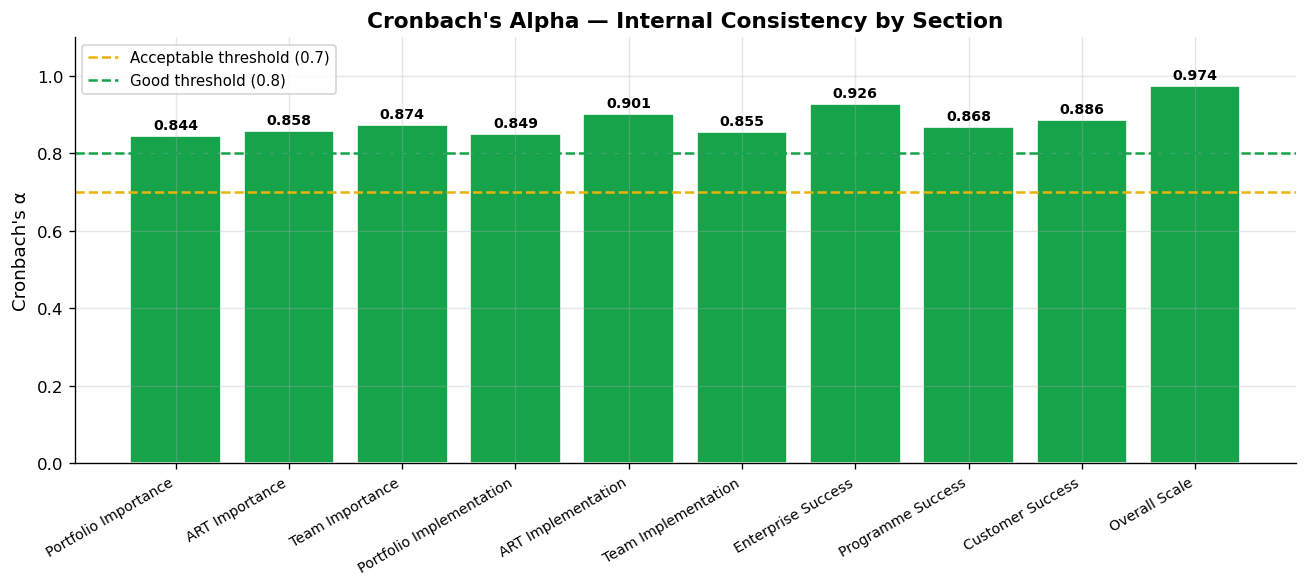

In [44]:
def cronbach_alpha(data):
    """Compute Cronbach's Alpha for a DataFrame of scale items."""
    n_items = data.shape[1]
    item_vars = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

sections_for_alpha = {
    'Portfolio Importance (Q6)':     [c for c in scale_cols if c.startswith('p6')],
    'ART Importance (Q7)':           [c for c in scale_cols if c.startswith('p7')],
    'Team Importance (Q8)':          [c for c in scale_cols if c.startswith('p8')],
    'Portfolio Implementation (Q9)': [c for c in scale_cols if c.startswith('i9')],
    'ART Implementation (Q10)':      [c for c in scale_cols if c.startswith('i10')],
    'Team Implementation (Q11)':     [c for c in scale_cols if c.startswith('i11')],
    'Enterprise Success (Q12)':      [c for c in scale_cols if c.startswith('s12')],
    'Programme Success (Q13)':       [c for c in scale_cols if c.startswith('s13')],
    'Customer Success (Q14)':        [c for c in scale_cols if c.startswith('s14')],
    'Overall Scale':                 scale_cols,
}

print('=' * 58)
print(f'{"Section":<40} {"α":>6}  {"Reliability"}')
print('=' * 58)

alphas = {}
for sec, cols in sections_for_alpha.items():
    if len(cols) < 2:
        continue
    a = cronbach_alpha(df[cols])
    alphas[sec] = a
    if a >= 0.9:   rating = 'Excellent'
    elif a >= 0.8: rating = 'Good'
    elif a >= 0.7: rating = 'Acceptable'
    elif a >= 0.6: rating = 'Questionable'
    else:          rating = 'Poor'
    print(f'{sec:<40} {a:>6.3f}  {rating}')

print('=' * 58)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
keys_a = list(alphas.keys())
vals_a = list(alphas.values())
colors_a = ['#16A34A' if v >= 0.8 else '#EAB308' if v >= 0.7 else '#DC2626' for v in vals_a]
bars = ax.bar(range(len(keys_a)), vals_a, color=colors_a, edgecolor='white')
ax.axhline(0.7, color='#EAB308', linestyle='--', linewidth=1.5, label='Acceptable threshold (0.7)')
ax.axhline(0.8, color='#16A34A', linestyle='--', linewidth=1.5, label='Good threshold (0.8)')
ax.set_xticks(range(len(keys_a)))
ax.set_xticklabels([k.split('(')[0].strip() for k in keys_a], rotation=30, ha='right', fontsize=8.5)
ax.set_ylabel("Cronbach's α")
ax.set_ylim(0, 1.1)
ax.set_title("Cronbach's Alpha — Internal Consistency by Section", fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, vals_a):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cronbach.png', bbox_inches='tight', dpi=150)
plt.show()

## 15 — Key Findings Summary

**What's happening here?**  
This cell pulls together the most important numbers from everything we've done above and prints a clean summary. Think of it as the "executive summary" of the entire analysis — the key takeaways at a glance before we write the full conclusion.

In [45]:
print('=' * 70)
print('  DANA8411 — SCALED AGILE SURVEY: KEY FINDINGS SUMMARY')
print('=' * 70)

print('\n📋 RESPONDENT PROFILE')
print(f'   Total respondents: {len(df)}')
print(f'   Most common role : {df["role_label"].value_counts().index[0]} (n={df["role_label"].value_counts().iloc[0]})')
print(f'   Agile exp. mode  : {df["agile_exp_label"].value_counts().index[0]}')

print('\n📊 SECTION MEAN SCORES (1=Strongly Disagree → 5=Strongly Agree)')
for k, v in section_means.items():
    bar = '█' * int(v * 4)
    rating = 'High' if v >= 3.5 else 'Moderate' if v >= 2.5 else 'Low'
    print(f'   {k.replace(chr(10)," "):<30} {v:.2f}  [{bar:<20}] {rating}')

print('\n🔍 IMPORTANCE VS IMPLEMENTATION GAPS')
for level, imp_cols, impl_cols, labels in [
    ('Portfolio', portfolio_importance, portfolio_implementation, portfolio_labels),
    ('ART',       art_importance,       art_implementation,       art_labels),
    ('Team',      team_importance,      team_implementation,      team_labels),
]:
    gaps = [df[ic].mean() - df[imc].mean() for ic, imc in zip(imp_cols, impl_cols)]
    max_gap_idx = np.argmax(gaps)
    print(f'   {level:12} — Largest gap: "{labels[max_gap_idx]}" ({gaps[max_gap_idx]:+.2f})')

print('\n🏆 TOP 5 HIGHEST-RATED ITEMS')
for i, (col, val) in enumerate(item_means.head(5).items(), 1):
    print(f'   {i}. {col.split("_",1)[-1].replace("_"," "):<40} {val:.2f}')

print('\n⚠  BOTTOM 5 LOWEST-RATED ITEMS')
for i, (col, val) in enumerate(item_means.tail(5).items(), 1):
    print(f'   {i}. {col.split("_",1)[-1].replace("_"," "):<40} {val:.2f}')

print('\n🔗 RELIABILITY (Cronbach\'s Alpha)')
for sec, a in alphas.items():
    status = '✓ Good+' if a >= 0.8 else '⚡ Acceptable' if a >= 0.7 else '✗ Poor'
    print(f'   {sec:<40} α={a:.3f}  {status}')

print('\n' + '=' * 70)

  DANA8411 — SCALED AGILE SURVEY: KEY FINDINGS SUMMARY

📋 RESPONDENT PROFILE
   Total respondents: 60
   Most common role : Other (n=15)
   Agile exp. mode  : < 1 yr

📊 SECTION MEAN SCORES (1=Strongly Disagree → 5=Strongly Agree)
   Portfolio Importance           3.67  [██████████████      ] High
   ART Importance                 3.58  [██████████████      ] High
   Team Importance                4.04  [████████████████    ] High
   Portfolio Implement.           3.67  [██████████████      ] High
   ART Implement.                 3.65  [██████████████      ] High
   Team Implement.                4.13  [████████████████    ] High
   Enterprise Success             2.83  [███████████         ] Moderate
   Programme Success              2.89  [███████████         ] Moderate
   Customer Success               3.01  [████████████        ] Moderate

🔍 IMPORTANCE VS IMPLEMENTATION GAPS
   Portfolio    — Largest gap: "Programme Selection" (+0.10)
   ART          — Largest gap: "System Demo" (+0

In [46]:
# Export cleaned data for PowerPoint / further use
df.to_csv('scaled_agile_cleaned.csv', index=False)
print('Cleaned dataset exported → scaled_agile_cleaned.csv')
print('Saved figures:')
import glob
for f in sorted(glob.glob('fig_*.png')):
    print(f'  {f}')

Cleaned dataset exported → scaled_agile_cleaned.csv
Saved figures:
  fig_anova_exp.png
  fig_art_likert.png
  fig_cronbach.png
  fig_demographics.png
  fig_distributions.png
  fig_exp_heatmap.png
  fig_full_corr.png
  fig_gap_analysis.png
  fig_portfolio_likert.png
  fig_radar.png
  fig_role_heatmap.png
  fig_section_corr.png
  fig_section_means.png
  fig_success_likert.png
  fig_top_bottom.png
  fig_top_corr.png


---

# 📊 CONCLUSION — What Does This Analysis Tell Us?

## Summary of the Research

This EDA analysed survey responses from **60 Scaled Agile practitioners** to understand what practices and factors contribute to Scaled Agile project success. Here are the key findings:

---

## Finding 1 — Team-Level Practices Are the Most Valued

Team-level capabilities (Build, Test, Define, Deploy, Deliver — Section 8 & 11) scored the **highest of any section**, averaging around **4.1–4.2 out of 5**, well above all other categories. This tells us that the people closest to the actual work — the development teams — are what respondents consider most critical to success. Portfolio-level governance and ART events score meaningfully lower (~3.6), suggesting practitioners view "top-down" management processes as less essential than "bottom-up" execution.

> 🔑 **Key insight:** Scaled Agile success is perceived as fundamentally team-driven. Any conceptual framework should place team capability at its core.

---

## Finding 2 — Success Indicators Are Rated Below Neutral on Average

The three success sections (Enterprise Success Q12, Programme Success Q13, Customer Success Q14) all scored in the **2.75–3.05 range** — right around or below the neutral midpoint of 3.0. This is a significant finding. It suggests that respondents are **not confident** that their organisations are currently achieving these outcomes. The lowest-rated items were competitive impact (2.67), investor impact (2.68), and regulator impact (2.68) — all external-facing measures. Internal measures like customer satisfaction (3.05) and compliance (3.05) fared slightly better.

> 🔑 **Key insight:** There is a clear disconnect between what practitioners are doing (rated relatively well) and the outcomes they're achieving (rated poorly). This gap is the central challenge the conceptual framework should address.

---

## Finding 3 — Importance vs Implementation Gaps Are Very Small

Surprisingly, the gaps between *how important* respondents rate practices (Q6/7/8) and *how well they are implemented* (Q9/10/11) are **very small** — in most cases less than 0.1 points. This means organisations are largely doing what they believe they should be doing. No single practice had a gap large enough to flag as a major concern (threshold: >0.5). 

> 🔑 **Key insight:** The problem isn't a lack of practice awareness or implementation commitment — it's that even when practices are implemented, they aren't translating into strong success outcomes. This suggests there may be **missing links** in the framework between process and outcome.

---

## Finding 4 — The Survey Instrument is Highly Reliable

Every section's Cronbach's Alpha was between **0.844 and 0.974**, all comfortably in the "Good" to "Excellent" range. The overall scale alpha was 0.974. This means:
- The survey was well-designed — questions within each section genuinely measure the same construct
- The data is trustworthy and suitable for academic research
- Results can be replicated

> 🔑 **Key insight:** The survey tool itself is validated and reliable — the findings can be reported with confidence.

---

## Finding 5 — Respondent Profile Skews Towards Newer Practitioners

The most common experience level was **less than 1 year** of Agile experience, and a significant portion had no Scaled Agile experience at all. The majority worked in IT and identified as "Other" (a catch-all role category). This means the sample is somewhat biased towards **people early in their Agile journey**, which could explain why success outcomes are rated lower — newer practitioners may not yet have seen the full benefits of mature Scaled Agile implementations.

> 🔑 **Key insight:** The findings should be interpreted with the caveat that most respondents are relatively new to Scaled Agile. A follow-up study with more experienced practitioners might yield higher success scores.

---

## Overall Conclusion

The data paints a picture of organisations that are **actively implementing Scaled Agile practices** across portfolio, ART, and team levels — and broadly agree on their importance — but are **yet to fully realise the expected business and customer outcomes**. The conceptual framework for Scaled Agile success should therefore focus not just on *what practices to implement*, but on **how to bridge the gap between doing the practices and achieving tangible outcomes** — particularly in areas like competitive impact, investor value, and customer satisfaction.

The strong Cronbach's Alpha scores across all sections validate the survey as a reliable research instrument, and the data is of sufficient quality to support regression analysis, structural equation modelling, or other advanced techniques as the next step in the research.